In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================================================================
# MACHINE LEARNING AND DEEP LEARNING FOR LOAN PREDICTION IN BANKING
# Exploring Ensemble Methods and Data Balancing
# Complete Implementation
# =====================================================================

# Cell 1: Install Required Packages
!pip install -q imbalanced-learn xgboost lightgbm catboost scikit-optimize shap lime tensorflow seaborn plotly


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.9 MB/s eta 0:00:00


In [ ]:
# Cell 2: Import Libraries and Mount Drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, matthews_corrcoef, confusion_matrix,
                           classification_report, roc_curve, auc)

# ML Algorithms
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                            GradientBoostingClassifier, VotingClassifier,
                            BaggingClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Interpretability
import shap
import lime
import lime.lime_tabular

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

print("🚀 All libraries imported successfully!")
print(f"📅 Analysis started at: {datetime.now()}")

🚀 All libraries imported successfully!
📅 Analysis started at: 2025-09-03 00:04:44.695086


In [ ]:
# Cell 3: Data Loading and Initial Exploration
# Load the dataset
DATA_PATH = '/content/drive/MyDrive/loan_project/loan_default.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
    print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

# Display basic information
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes.value_counts())



✅ Dataset loaded successfully!
📊 Dataset shape: (255347, 18)
💾 Memory usage: 126.81 MB

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 1


🔥 GENERATING FIGURE 2: HEAT MAP
Numerical columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']


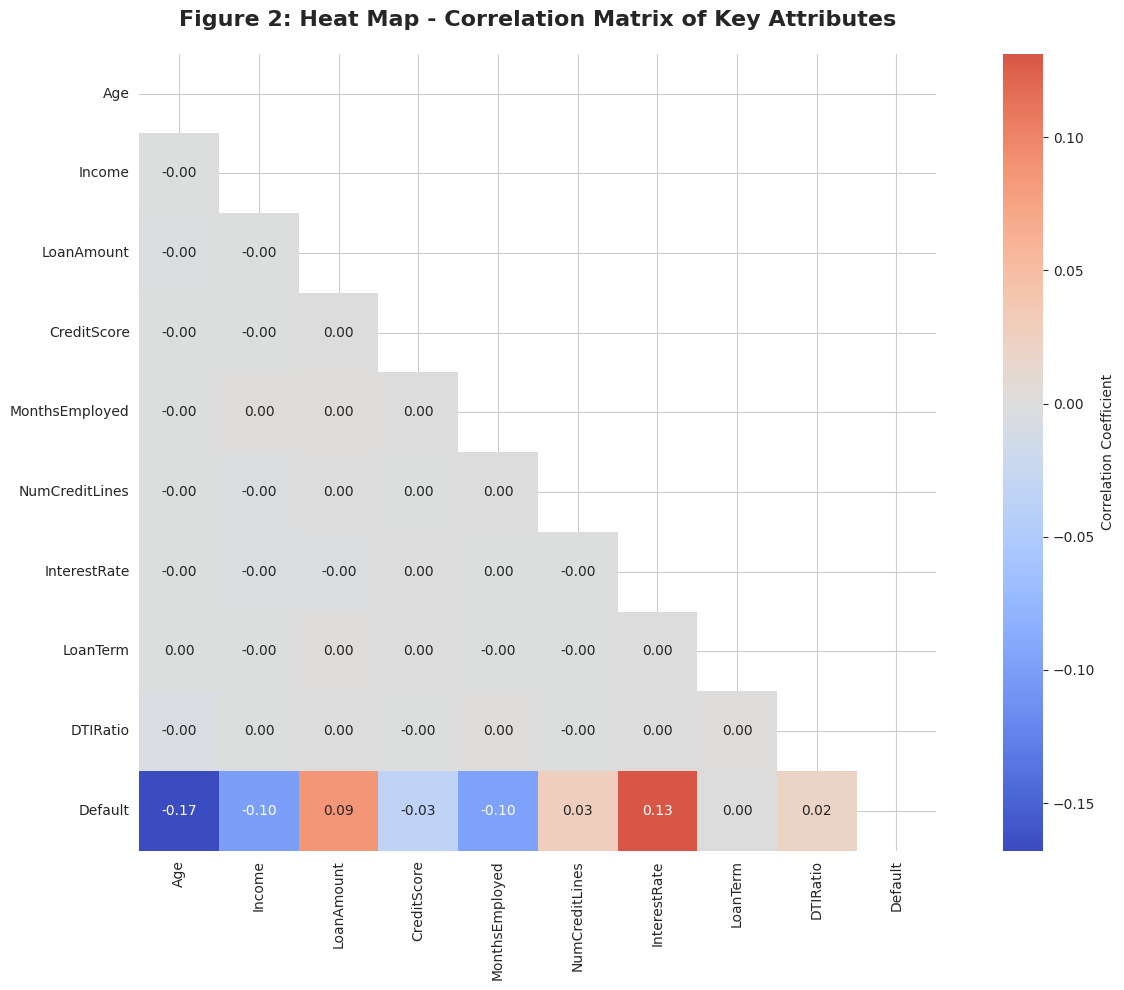

In [ ]:
# Cell 4: Data Analysis - Figure 2 (Heat Map)
print("\n🔥 GENERATING FIGURE 2: HEAT MAP")
print("="*50)

# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Create correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
           annot=True,
           cmap='coolwarm',
           center=0,
           square=True,
           fmt='.2f',
           cbar_kws={'label': 'Correlation Coefficient'},
           mask=mask)
plt.title('Figure 2: Heat Map - Correlation Matrix of Key Attributes',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



📊 GENERATING FIGURES 3-5: DISTRIBUTION ANALYSIS


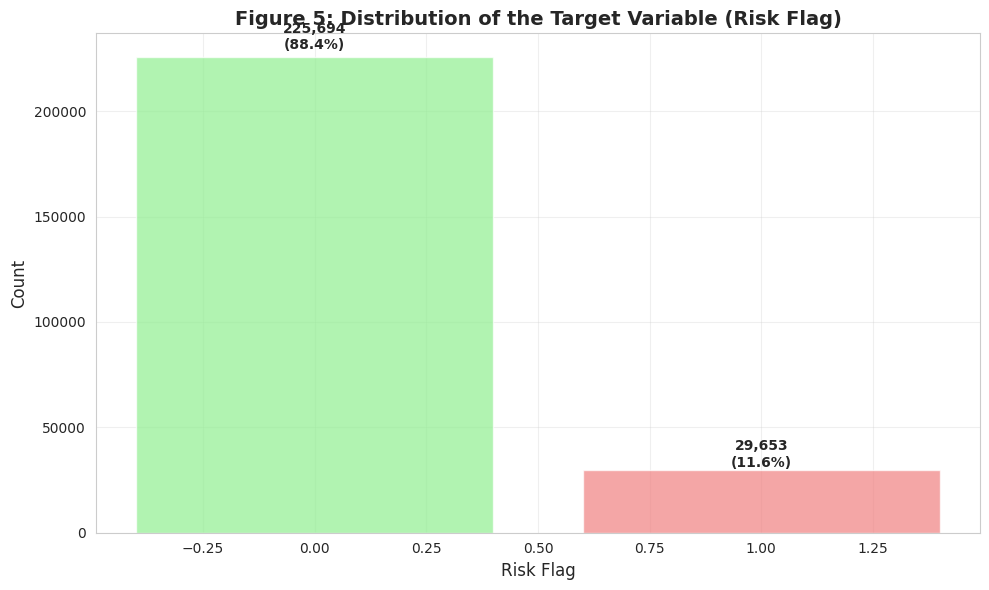

Target variable distribution:
Default
0    225694
1     29653
Name: count, dtype: int64
Class imbalance ratio: 7.61:1


In [ ]:
# Cell 5: Data Analysis - Distribution Analysis (Figures 3-5)
print("\n📊 GENERATING FIGURES 3-5: DISTRIBUTION ANALYSIS")
print("="*50)

# Function to create distribution plots
def create_distribution_plot(data, column, hue=None, title="", bins=30):
    plt.figure(figsize=(12, 6))
    if hue and hue in data.columns:
        sns.histplot(data=data, x=column, hue=hue, bins=bins, kde=True, alpha=0.7)
    else:
        sns.histplot(data=data, x=column, bins=bins, kde=True, alpha=0.7)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Figure 3: Distribution of house ownership status according to current job years
if 'Years_in_current_job' in df.columns and 'Home_Ownership' in df.columns:
    create_distribution_plot(df, 'Years_in_current_job', 'Home_Ownership',
                           'Figure 3: Distribution of House Ownership Status According to Current Job Years')

# Figure 4: Distribution of current job years according to house ownership status
if 'Home_Ownership' in df.columns:
    plt.figure(figsize=(12, 6))
    df['Home_Ownership'].value_counts().plot(kind='bar', color='skyblue', alpha=0.7)
    plt.title('Figure 4: Distribution of Current Job Years According to House Ownership Status',
              fontsize=14, fontweight='bold')
    plt.xlabel('Home Ownership Status', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Figure 5: Distribution of the target variable (Risk Flag)
target_col = 'Risk_Flag' if 'Risk_Flag' in df.columns else df.columns[-1]
plt.figure(figsize=(10, 6))
target_counts = df[target_col].value_counts()
colors = ['lightgreen', 'lightcoral']
bars = plt.bar(target_counts.index, target_counts.values, color=colors, alpha=0.7)
plt.title('Figure 5: Distribution of the Target Variable (Risk Flag)',
          fontsize=14, fontweight='bold')
plt.xlabel('Risk Flag', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on bars
for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + count*0.01,
             f'{count:,}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Target variable distribution:")
print(target_counts)
print(f"Class imbalance ratio: {target_counts.max()/target_counts.min():.2f}:1")


In [ ]:
# Cell 6: Data Preprocessing
print("\n🔧 DATA PREPROCESSING")
print("="*50)

# Make a copy for preprocessing
df_processed = df.copy()

# 1. Remove ID column if exists
id_cols = ['Id', 'ID', 'id', 'index']
for col in id_cols:
    if col in df_processed.columns:
        df_processed = df_processed.drop(columns=[col])
        print(f"✅ Removed {col} column")

print(f"Dataset shape after removing ID: {df_processed.shape}")

# 2. Identify feature types
target_column = target_col
feature_columns = [col for col in df_processed.columns if col != target_column]

numerical_features = df_processed[feature_columns].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_processed[feature_columns].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n📋 Feature Analysis:")
print(f"Target column: {target_column}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# 3. Handle missing values
print(f"\n🔍 Handling Missing Values:")
missing_summary = df_processed.isnull().sum()
if missing_summary.sum() > 0:
    print("Missing values found:")
    print(missing_summary[missing_summary > 0])

    # Fill numerical missing values with median
    for col in numerical_features:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)

    # Fill categorical missing values with mode
    for col in categorical_features:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

    print("✅ Missing values handled")
else:
    print("✅ No missing values found")

# 4. Encode categorical variables
print(f"\n🏷️ Encoding Categorical Variables:")
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {len(le.classes_)} unique values")

# 5. Prepare features and target
X = df_processed[feature_columns]
y = df_processed[target_column]

print(f"\n📊 Final dataset shape:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")



🔧 DATA PREPROCESSING
Dataset shape after removing ID: (255347, 18)

📋 Feature Analysis:
Target column: Default
Numerical features (9): ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical features (8): ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

🔍 Handling Missing Values:
✅ No missing values found

🏷️ Encoding Categorical Variables:
✅ Encoded LoanID: 255347 unique values
✅ Encoded Education: 4 unique values
✅ Encoded EmploymentType: 4 unique values
✅ Encoded MaritalStatus: 3 unique values
✅ Encoded HasMortgage: 2 unique values
✅ Encoded HasDependents: 2 unique values
✅ Encoded LoanPurpose: 5 unique values
✅ Encoded HasCoSigner: 2 unique values

📊 Final dataset shape:
Features (X): (255347, 17)
Target (y): (255347,)
Target distribution: {0: 225694, 1: 29653}


In [ ]:
# Cell 7: Train-Test Split and Feature Scaling
print("\n✂️ TRAIN-TEST SPLIT AND FEATURE SCALING")
print("="*50)

# Split the data (80-20 as mentioned in paper)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed (StandardScaler)")




✂️ TRAIN-TEST SPLIT AND FEATURE SCALING
Training set: (204277, 17)
Test set: (51070, 17)
Training target distribution: {0: 180555, 1: 23722}
Test target distribution: {0: 45139, 1: 5931}
✅ Feature scaling completed (StandardScaler)


In [ ]:
# New Cell 7A: Preprocessing Technique 1 — PowerTransformer (Yeo–Johnson)
# Goal: Reduce skewness in numeric features with a fast, light transform.
# Placement: Insert AFTER your current Cell 7 ("Train-Test Split and Feature Scaling").

from sklearn.preprocessing import PowerTransformer

print("\n🧪 EXTRA PREPROCESSING #1: Yeo–Johnson Power Transform")
print("="*50)

# Apply Yeo–Johnson on the scaled arrays (numeric-only)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ensure we have numpy arrays
import numpy as np
X_train_scaled = np.asarray(X_train_scaled)
X_test_scaled = np.asarray(X_test_scaled)

X_train_scaled = pt.fit_transform(X_train_scaled)
X_test_scaled  = pt.transform(X_test_scaled)

print("✅ Applied Yeo–Johnson transform (standardize=False)")
print("Shapes -> X_train_scaled:", X_train_scaled.shape, "| X_test_scaled:", X_test_scaled.shape)



🧪 EXTRA PREPROCESSING #1: Yeo–Johnson Power Transform
✅ Applied Yeo–Johnson transform (standardize=False)
Shapes -> X_train_scaled: (204277, 17) | X_test_scaled: (51070, 17)


In [ ]:
# New Cell 7B: Preprocessing Technique 2 — VarianceThreshold + SelectKBest
# Goal: Remove near-constant features and keep only the most informative ones (fast).
# Placement: Insert AFTER Cell 7A.

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
import numpy as np

print("\n🧪 EXTRA PREPROCESSING #2: VarianceThreshold + SelectKBest(mutual_info)")
print("="*50)

# 1) Drop near-constant features
vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt  = vt.transform(X_test_scaled)
print(f"VarianceThreshold -> kept {X_train_vt.shape[1]} features")

# 2) Keep top-K informative features using mutual information (fast & robust)
k_keep = min(40, X_train_vt.shape[1])  # cap to stay fast even on wide datasets
skb = SelectKBest(score_func=mutual_info_classif, k=k_keep)
X_train_skb = skb.fit_transform(X_train_vt, y_train)
X_test_skb  = skb.transform(X_test_vt)

# Overwrite the working feature matrices used downstream
X_train_scaled = X_train_skb
X_test_scaled  = X_test_skb

print(f"SelectKBest(mutual_info) -> kept top {k_keep} features")
print("✅ Feature selection done. New shapes ->", X_train_scaled.shape, X_test_scaled.shape)



🧪 EXTRA PREPROCESSING #2: VarianceThreshold + SelectKBest(mutual_info)
VarianceThreshold -> kept 17 features
SelectKBest(mutual_info) -> kept top 17 features
✅ Feature selection done. New shapes -> (204277, 17) (51070, 17)


In [ ]:
# Cell 8: Model Evaluation Functions
print("\n🎯 SETTING UP MODEL EVALUATION FUNCTIONS")
print("="*50)

def calculate_metrics(y_true, y_pred, y_proba=None, model_name="Model"):
    """Calculate all evaluation metrics"""
    metrics = {}

    # Basic metrics
    metrics['Model'] = model_name
    metrics['AC'] = accuracy_score(y_true, y_pred) * 100  # Accuracy
    metrics['PR'] = precision_score(y_true, y_pred, average='weighted') * 100  # Precision
    metrics['RE'] = recall_score(y_true, y_pred, average='weighted') * 100  # Recall
    metrics['FS'] = f1_score(y_true, y_pred, average='weighted') * 100  # F1-Score

    # AUC-ROC (if probabilities available)
    if y_proba is not None:
        if len(np.unique(y_true)) == 2:  # Binary classification
            metrics['AUC'] = roc_auc_score(y_true, y_proba) * 100
        else:  # Multi-class
            metrics['AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr') * 100
    else:
        metrics['AUC'] = np.nan

    # Matthews Correlation Coefficient
    metrics['MCC'] = matthews_corrcoef(y_true, y_pred) * 100

    return metrics

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Evaluate model on both training and test sets"""
    results = []

    # Training evaluation
    try:
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, 'predict_proba') else None
        train_metrics = calculate_metrics(y_train, y_train_pred, y_train_proba, f"{model_name} (Train)")
        results.append(train_metrics)
    except Exception as e:
        print(f"Warning: Training evaluation failed for {model_name}: {e}")

    # Test evaluation
    try:
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        test_metrics = calculate_metrics(y_test, y_test_pred, y_test_proba, f"{model_name} (Test)")
        results.append(test_metrics)
    except Exception as e:
        print(f"Warning: Test evaluation failed for {model_name}: {e}")

    return results

print("✅ Evaluation functions ready")




🎯 SETTING UP MODEL EVALUATION FUNCTIONS
✅ Evaluation functions ready


In [ ]:
# Cell 9: Machine Learning Models (Table 2 Results)
print("\n🤖 MACHINE LEARNING EXPERIMENTS - TABLE 2")
print("="*50)

# Define ML models as per the paper
ml_models = {
    'Gaussian NB': GaussianNB(),
    'K Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Logistic Reg': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Store results
ml_results = []

print("Training and evaluating ML models...")
for name, model in ml_models.items():
    print(f"🔄 Training {name}...")
    try:
        # Fit model
        model.fit(X_train_scaled, y_train)

        # Evaluate model
        results = evaluate_model(model, X_train_scaled, y_train,
                               X_test_scaled, y_test, name)
        ml_results.extend(results)

        print(f"✅ {name} completed")
    except Exception as e:
        print(f"❌ {name} failed: {e}")

# Create results DataFrame
ml_results_df = pd.DataFrame(ml_results)
print("\n📊 TABLE 2: MACHINE LEARNING RESULTS")
print("="*50)
print(ml_results_df.round(2))




🤖 MACHINE LEARNING EXPERIMENTS - TABLE 2
Training and evaluating ML models...
🔄 Training Gaussian NB...
✅ Gaussian NB completed
🔄 Training K Neighbors...
✅ K Neighbors completed
🔄 Training Decision Tree...
✅ Decision Tree completed
🔄 Training Logistic Reg...
✅ Logistic Reg completed
🔄 Training Random Forest...
✅ Random Forest completed
🔄 Training AdaBoost...
✅ AdaBoost completed
🔄 Training Gradient Boosting...
✅ Gradient Boosting completed

📊 TABLE 2: MACHINE LEARNING RESULTS
                        Model      AC      PR      RE      FS     AUC    MCC
0         Gaussian NB (Train)   88.48   85.92   88.48   83.35   74.61   9.23
1          Gaussian NB (Test)   88.46   85.68   88.46   83.31   75.11   8.55
2         K Neighbors (Train)   89.45   87.59   89.45   86.46   88.66  30.31
3          K Neighbors (Test)   87.35   82.05   87.35   83.65   61.62   9.41
4       Decision Tree (Train)   89.13   87.66   89.13   85.22   76.63  24.28
5        Decision Tree (Test)   88.09   83.18   88.09   


📊 GENERATING FIGURE 7: ML MODELS PERFORMANCE COMPARISON


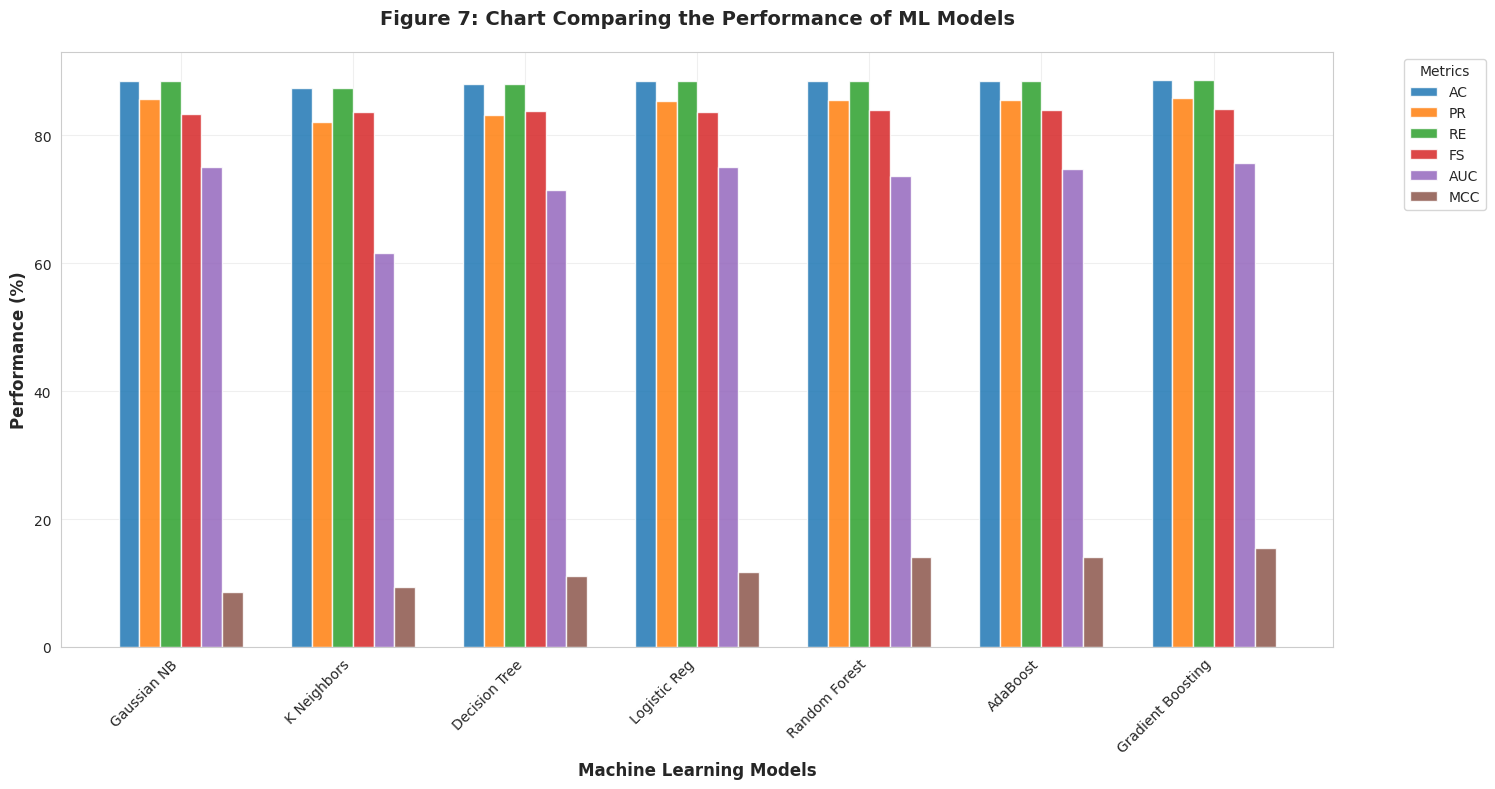

In [ ]:
# Cell 10: Figure 7 - ML Models Performance Comparison
print("\n📊 GENERATING FIGURE 7: ML MODELS PERFORMANCE COMPARISON")
print("="*50)

# Filter only test results for plotting (so Train scores don't clutter chart)
ml_test_results = ml_results_df[ml_results_df['Model'].str.contains('Test')].copy()

# Clean model names (remove " (Test)" suffix)
ml_test_results['Model'] = ml_test_results['Model'].str.replace(' (Test)', '', regex=False)

# Define metrics to plot
metrics_to_plot = ['AC', 'PR', 'RE', 'FS', 'AUC', 'MCC']
x_labels = ml_test_results['Model'].values

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(15, 8))
x_pos = np.arange(len(x_labels))
width = 0.12

# Extend colors if more models/metrics are added later
colors = ['#1f77b4', '#ff7f0e', '#2ca02c',
          '#d62728', '#9467bd', '#8c564b',
          '#e377c2', '#7f7f7f']  # extra fallback colors

for i, metric in enumerate(metrics_to_plot):
    values = ml_test_results[metric].fillna(0).values
    ax.bar(x_pos + i * width, values, width,
           label=metric, color=colors[i % len(colors)], alpha=0.85)

# Labels and formatting
ax.set_xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold')
ax.set_title('Figure 7: Chart Comparing the Performance of ML Models',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos + width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 11: Deep Learning Model Architecture Functions
print("\n🧠 DEEP LEARNING MODEL ARCHITECTURES")
print("="*50)

def create_mlp_model(input_shape, name="MLP"):
    """Multi-Layer Perceptron"""
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(input_shape,)))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def create_cnn_model(input_shape, name="CNN"):
    """1D CNN for tabular data"""
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(input_shape, 1)))
    model.add(layers.Conv1D(64, 3, activation='relu'))
    model.add(layers.Conv1D(64, 3, activation='relu'))
    model.add(layers.GlobalMaxPooling1D())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def create_lstm_model(input_shape, name="LSTM"):
    """LSTM model"""
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(input_shape, 1)))
    model.add(layers.LSTM(64, return_sequences=True))
    model.add(layers.LSTM(32))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def create_gru_model(input_shape, name="GRU"):
    """GRU model"""
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=(input_shape, 1)))
    model.add(layers.GRU(64, return_sequences=True))
    model.add(layers.GRU(32))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def create_autoencoder_model(input_shape, name="Autoencoder"):
    """Autoencoder-based classifier"""
    # Encoder
    input_layer = layers.Input(shape=(input_shape,))
    encoded = layers.Dense(128, activation='relu')(input_layer)
    encoded = layers.Dense(64, activation='relu')(encoded)
    encoded = layers.Dense(32, activation='relu')(encoded)

    # Decoder
    decoded = layers.Dense(64, activation='relu')(encoded)
    decoded = layers.Dense(128, activation='relu')(decoded)
    decoded = layers.Dense(input_shape, activation='sigmoid')(decoded)

    # Classifier head
    classifier = layers.Dense(64, activation='relu')(encoded)
    classifier = layers.Dropout(0.3)(classifier)
    classifier = layers.Dense(1, activation='sigmoid')(classifier)

    model = models.Model(inputs=input_layer, outputs=classifier, name=name)
    return model

def create_densenet_model(input_shape, name="DenseNet"):
    """DenseNet-inspired model for tabular data"""
    input_layer = layers.Input(shape=(input_shape,))

    # Dense block 1
    x1 = layers.Dense(128, activation='relu')(input_layer)
    x1 = layers.Dropout(0.2)(x1)

    # Dense block 2
    x2 = layers.concatenate([input_layer, x1])
    x2 = layers.Dense(128, activation='relu')(x2)
    x2 = layers.Dropout(0.2)(x2)

    # Dense block 3
    x3 = layers.concatenate([input_layer, x1, x2])
    x3 = layers.Dense(64, activation='relu')(x3)
    x3 = layers.Dropout(0.2)(x3)

    # Final layers
    output = layers.Dense(32, activation='relu')(x3)
    output = layers.Dropout(0.3)(output)
    output = layers.Dense(1, activation='sigmoid')(output)

    model = models.Model(inputs=input_layer, outputs=output, name=name)
    return model

def create_resnet_model(input_shape, name="ResNet"):
    """ResNet-inspired model for tabular data"""
    input_layer = layers.Input(shape=(input_shape,))

    # Initial layer
    x = layers.Dense(128, activation='relu')(input_layer)

    # Residual block 1
    residual = x
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.add([x, residual])  # Skip connection

    # Residual block 2
    residual = x
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.add([x, residual])  # Skip connection

    # Final layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=input_layer, outputs=output, name=name)
    return model

print("✅ Deep Learning architectures defined")




🧠 DEEP LEARNING MODEL ARCHITECTURES
✅ Deep Learning architectures defined


In [ ]:
# New Cell 11A: Define 2 extra DL architectures — GLU-MLP and Tiny Transformer
# Placement: Insert AFTER your current Cell 11 ("Deep Learning Model Architecture Functions").

from tensorflow import keras
from tensorflow.keras import layers, models

print("\n🧩 EXTRA DL ARCHITECTURES: GLU-MLP & TransformerTab")
print("="*50)

def create_glu_mlp_model(input_shape, name="GLU-MLP"):
    """Gated Linear Unit MLP — fast, regularized MLP variant"""
    inputs = layers.Input(shape=(input_shape,))
    linear = layers.Dense(128)(inputs)
    gate   = layers.Dense(128, activation="sigmoid")(inputs)
    x = layers.Multiply()([linear, gate])
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs, name=name)
    return model

def create_transformer_tabular_model(input_shape, name="TransformerTab"):
    """A tiny Transformer-style encoder for tabular data (very small to stay fast)."""
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Reshape((input_shape, 1))(inputs)
    x = layers.Dense(16)(x)  # project to small d_model
    attn = layers.MultiHeadAttention(num_heads=1, key_dim=16)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, outputs, name=name)
    return model

print("✅ Extra architectures registered")



🧩 EXTRA DL ARCHITECTURES: GLU-MLP & TransformerTab
✅ Extra architectures registered


In [ ]:
# Cell 12: Deep Learning Training Function
def train_dl_model(model_func, X_train, y_train, X_test, y_test,
                   model_name, epochs=10, batch_size=64, validation_split=0.2):
    """Train and evaluate deep learning model"""
    print(f"🔄 Training {model_name}...")

    # Prepare data shape for different model types
    if model_name in ['CNN', 'LSTM', 'GRU']:
        X_train_shaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test_shaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)  # CORRECT
        input_shape = X_train.shape[1]
    else:
        X_train_shaped = X_train
        X_test_shaped = X_test
        input_shape = X_train.shape[1]

    # Create model
    model = model_func(input_shape, model_name)

    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    # Callbacks
    callbacks_list = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
    ]

    try:
        # Train model
        history = model.fit(
            X_train_shaped, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks_list,
            verbose=0
        )

        # Make predictions
        y_train_pred_proba = model.predict(X_train_shaped, verbose=0)
        y_test_pred_proba = model.predict(X_test_shaped, verbose=0)

        y_train_pred = (y_train_pred_proba > 0.5).astype(int).ravel()
        y_test_pred = (y_test_pred_proba > 0.5).astype(int).ravel()

        # Calculate metrics
        train_metrics = calculate_metrics(y_train, y_train_pred,
                                        y_train_pred_proba.ravel(), f"{model_name} (Train)")
        test_metrics = calculate_metrics(y_test, y_test_pred,
                                       y_test_pred_proba.ravel(), f"{model_name} (Test)")

        print(f"✅ {model_name} completed")
        return [train_metrics, test_metrics], history

    except Exception as e:
        print(f"❌ {model_name} failed: {e}")
        return [], None



In [ ]:
# Cell 13: Deep Learning without Balancing (Table 3)
print("\n🧠 DEEP LEARNING WITHOUT BALANCING - TABLE 3")
print("="*50)

# Define DL models
dl_models = {
    'MLP': create_mlp_model,
    'CNN': create_cnn_model,
    'LSTM': create_lstm_model,
    'GRU': create_gru_model,
    'Autoencoder': create_autoencoder_model,
    'ResNet': create_resnet_model,
    'DenseNet': create_densenet_model
}

# Train DL models without balancing
dl_results_no_balance = []
dl_histories = {}

for name, model_func in dl_models.items():
    results, history = train_dl_model(
        model_func, X_train_scaled, y_train, X_test_scaled, y_test,
        name, epochs=10, batch_size=64
    )
    dl_results_no_balance.extend(results)
    if history:
        dl_histories[name] = history

# Create results DataFrame
dl_no_balance_df = pd.DataFrame(dl_results_no_balance)
print("\n📊 TABLE 3: DEEP LEARNING RESULTS (No Balancing)")
print("="*50)
if not dl_no_balance_df.empty:
    print(dl_no_balance_df.round(2))


🧠 DEEP LEARNING WITHOUT BALANCING - TABLE 3
🔄 Training MLP...
✅ MLP completed
🔄 Training CNN...
✅ CNN completed
🔄 Training LSTM...
✅ LSTM completed
🔄 Training GRU...
✅ GRU completed
🔄 Training Autoencoder...
✅ Autoencoder completed
🔄 Training ResNet...
✅ ResNet completed
🔄 Training DenseNet...
✅ DenseNet completed

📊 TABLE 3: DEEP LEARNING RESULTS (No Balancing)
                  Model     AC     PR     RE     FS    AUC    MCC
0           MLP (Train)  88.62  85.48  88.62  84.43  75.73  17.17
1            MLP (Test)  88.62  85.48  88.62  84.47  75.70  17.39
2           CNN (Train)  88.51  85.27  88.51  83.71  66.37  12.07
3            CNN (Test)  88.50  85.18  88.50  83.69  65.78  11.80
4          LSTM (Train)  88.61  85.37  88.61  84.64  75.34  18.27
5           LSTM (Test)  88.65  85.52  88.65  84.72  75.75  18.88
6           GRU (Train)  88.59  86.25  88.59  83.75  75.31  13.25
7            GRU (Test)  88.59  86.24  88.59  83.77  75.67  13.35
8   Autoencoder (Train)  88.68  85.81  8

In [ ]:
# Cell 14: SMOTE and SMOTE-TOMEK Data Balancing
print("\n⚖️ DATA BALANCING WITH SMOTE AND SMOTE-TOMEK")
print("="*50)

# SMOTE balancing
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")
print(f"Original class distribution: {np.bincount(y_train)}")
print(f"SMOTE class distribution: {np.bincount(y_train_smote)}")

# SMOTE-TOMEK balancing
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"SMOTE-TOMEK training shape: {X_train_smote_tomek.shape}")
print(f"SMOTE-TOMEK class distribution: {np.bincount(y_train_smote_tomek)}")

print("✅ Data balancing completed")




⚖️ DATA BALANCING WITH SMOTE AND SMOTE-TOMEK
Original training shape: (204277, 17)
SMOTE training shape: (361110, 17)
Original class distribution: [180555  23722]
SMOTE class distribution: [180555 180555]
SMOTE-TOMEK training shape: (361048, 17)
SMOTE-TOMEK class distribution: [180524 180524]
✅ Data balancing completed


In [ ]:
# Cell 15: Deep Learning with SMOTE-TOMEK (Table 4)
print("\n🧠 DEEP LEARNING WITH SMOTE-TOMEK - TABLE 4")
print("="*50)

dl_results_smote_tomek = []

for name, model_func in dl_models.items():
    results, history = train_dl_model(
        model_func, X_train_smote_tomek, y_train_smote_tomek,
        X_test_scaled, y_test, name, epochs=10, batch_size=64
    )
    dl_results_smote_tomek.extend(results)

# Create results DataFrame
dl_smote_tomek_df = pd.DataFrame(dl_results_smote_tomek)
print("\n📊 TABLE 4: DEEP LEARNING RESULTS (SMOTE-TOMEK)")
print("="*50)
if not dl_smote_tomek_df.empty:
    print(dl_smote_tomek_df.round(2))




🧠 DEEP LEARNING WITH SMOTE-TOMEK - TABLE 4
🔄 Training MLP...
✅ MLP completed
🔄 Training CNN...
✅ CNN completed
🔄 Training LSTM...
✅ LSTM completed
🔄 Training GRU...
✅ GRU completed
🔄 Training Autoencoder...
✅ Autoencoder completed
🔄 Training ResNet...
✅ ResNet completed
🔄 Training DenseNet...
✅ DenseNet completed

📊 TABLE 4: DEEP LEARNING RESULTS (SMOTE-TOMEK)
                  Model     AC     PR     RE     FS    AUC    MCC
0           MLP (Train)  73.23  73.91  73.23  73.04  82.04  47.13
1            MLP (Test)  77.22  84.81  77.22  80.18  73.54  23.99
2           CNN (Train)  81.48  82.37  81.48  81.36  89.01  63.85
3            CNN (Test)  81.79  82.06  81.79  81.92  64.68  12.60
4          LSTM (Train)  84.04  85.55  84.04  83.87  91.95  69.57
5           LSTM (Test)  86.39  84.56  86.39  85.33  74.79  24.33
6           GRU (Train)  85.43  86.44  85.43  85.33  92.75  71.86
7            GRU (Test)  85.78  84.00  85.78  84.78  74.10  21.74
8   Autoencoder (Train)  75.78  75.95  75.

In [ ]:
# Cell 16: Deep Learning with SMOTE (Table 5)
print("\n🧠 DEEP LEARNING WITH SMOTE - TABLE 5")
print("="*50)

dl_results_smote = []

for name, model_func in dl_models.items():
    results, history = train_dl_model(
        model_func, X_train_smote, y_train_smote,
        X_test_scaled, y_test, name, epochs=10, batch_size=64
    )
    dl_results_smote.extend(results)

# Create results DataFrame
dl_smote_df = pd.DataFrame(dl_results_smote)
print("\n📊 TABLE 5: DEEP LEARNING RESULTS (SMOTE)")
print("="*50)
if not dl_smote_df.empty:
    print(dl_smote_df.round(2))




🧠 DEEP LEARNING WITH SMOTE - TABLE 5
🔄 Training MLP...
✅ MLP completed
🔄 Training CNN...
✅ CNN completed
🔄 Training LSTM...
✅ LSTM completed
🔄 Training GRU...
✅ GRU completed
🔄 Training Autoencoder...
✅ Autoencoder completed
🔄 Training ResNet...
✅ ResNet completed
🔄 Training DenseNet...
✅ DenseNet completed

📊 TABLE 5: DEEP LEARNING RESULTS (SMOTE)
                  Model     AC     PR     RE     FS    AUC    MCC
0           MLP (Train)  73.05  73.84  73.05  72.82  82.15  46.89
1            MLP (Test)  77.72  84.80  77.72  80.51  73.57  24.12
2           CNN (Train)  81.56  83.53  81.56  81.29  89.28  65.06
3            CNN (Test)  84.36  81.69  84.36  82.89  63.76  10.53
4          LSTM (Train)  85.44  87.62  85.44  85.22  93.05  73.02
5           LSTM (Test)  88.03  84.68  88.03  85.37  74.58  21.72
6           GRU (Train)  85.10  86.37  85.10  84.97  92.58  71.46
7            GRU (Test)  86.28  84.36  86.28  85.17  74.60  23.31
8   Autoencoder (Train)  75.71  75.93  75.71  75.66  8


📈 TRAINING LOSS CURVES (per DL model)


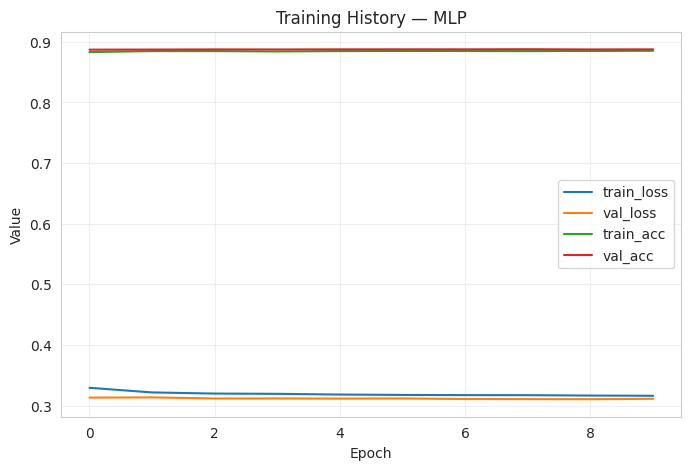

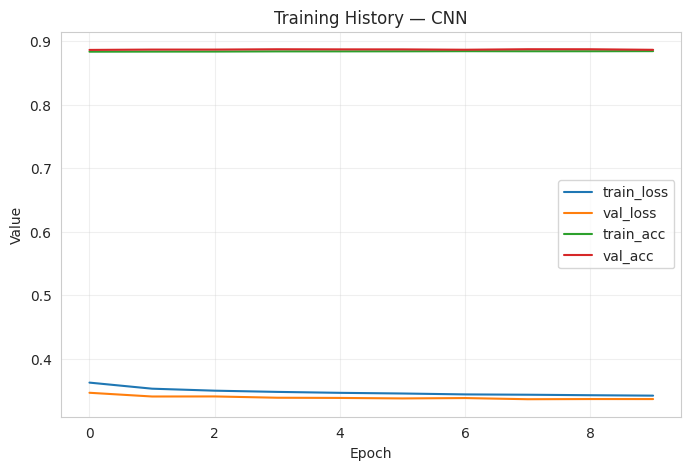

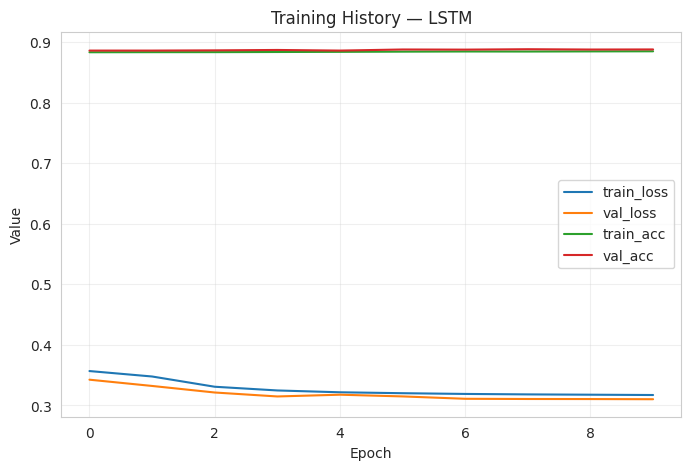

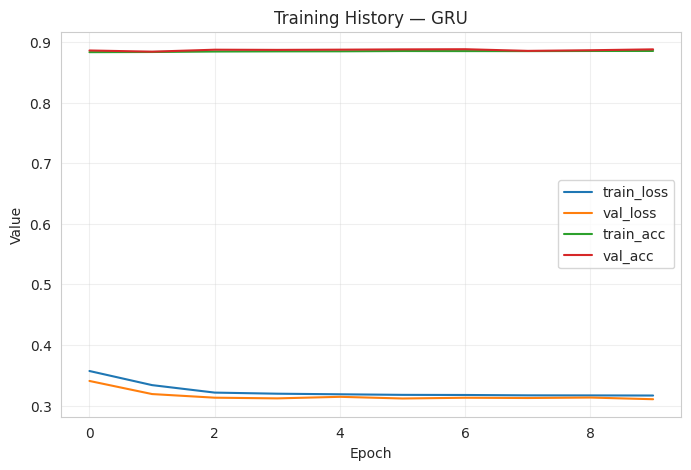

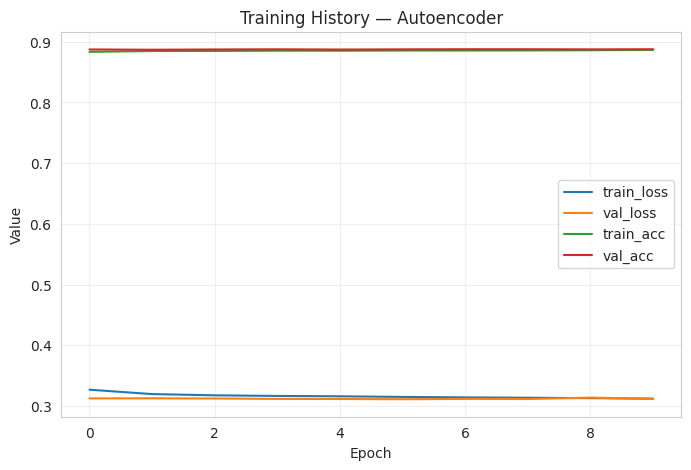

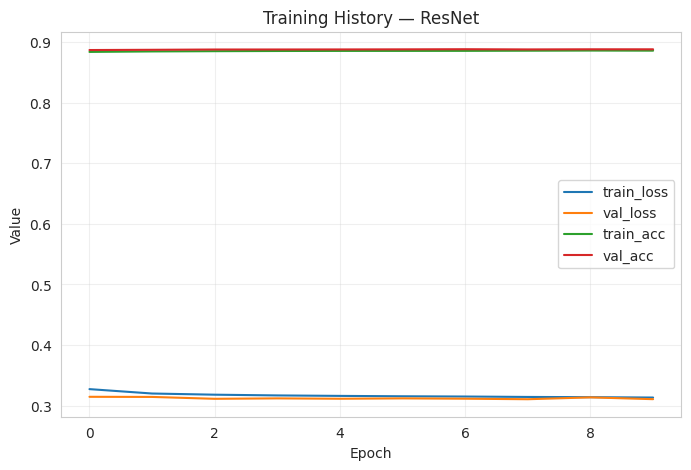

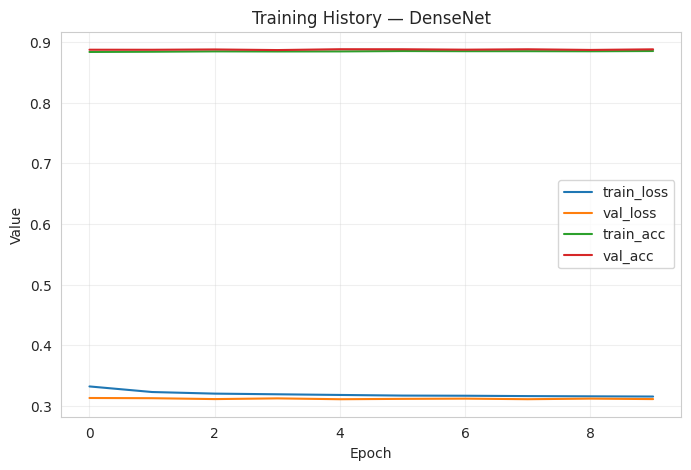

In [ ]:
# New Plot Cell P1: training_loss — DL losses/metrics across epochs
# Placement: Insert AFTER your current Cell 16 (after DL with SMOTE) so histories are populated.

import matplotlib.pyplot as plt

print("\n📈 TRAINING LOSS CURVES (per DL model)")
print("="*50)

if 'dl_histories' not in globals() or len(dl_histories) == 0:
    print("⚠️ No DL histories found. Run DL training cells first.")
else:
    for name, hist in dl_histories.items():
        hist_dict = hist.history if hasattr(hist, "history") else hist
        if not isinstance(hist_dict, dict) or "loss" not in hist_dict:
            continue
        plt.figure(figsize=(8,5))
        plt.plot(hist_dict.get("loss", []), label="train_loss")
        if "val_loss" in hist_dict:
            plt.plot(hist_dict["val_loss"], label="val_loss")
        if "accuracy" in hist_dict:
            plt.plot(hist_dict["accuracy"], label="train_acc")
        if "val_accuracy" in hist_dict:
            plt.plot(hist_dict["val_accuracy"], label="val_acc")
        plt.title(f"Training History — {name}")
        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


In [ ]:
# Cell 17: Ensemble Methods
print("\n🎭 ENSEMBLE METHODS")
print("="*50)

# Create ensemble models
ensemble_models = {
    'Voting Classifier': VotingClassifier([
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lr', LogisticRegression(random_state=42, max_iter=1000))
    ], voting='soft'),

    'Bagging Classifier': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42), # Changed base_estimator to estimator
        n_estimators=50, random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

# Train ensemble models
ensemble_results = []

for name, model in ensemble_models.items():
    print(f"🔄 Training {name}...")
    try:
        model.fit(X_train_scaled, y_train)
        results = evaluate_model(model, X_train_scaled, y_train,
                               X_test_scaled, y_test, name)
        ensemble_results.extend(results)
        print(f"✅ {name} completed")
    except Exception as e:
        print(f"❌ {name} failed: {e}")


🎭 ENSEMBLE METHODS
🔄 Training Voting Classifier...
✅ Voting Classifier completed
🔄 Training Bagging Classifier...
✅ Bagging Classifier completed
🔄 Training Extra Trees...
✅ Extra Trees completed


In [ ]:
# Cell 18: Deep Learning with Ensemble Methods (Table 6)
print("\n🧠 DEEP LEARNING WITH ENSEMBLE METHODS - TABLE 6")
print("="*50)

# For DL ensemble, we'll average predictions from multiple models
def create_dl_ensemble_prediction(models_dict, X_test):
    """Create ensemble prediction from multiple DL models"""
    predictions = []

    for name, model_func in models_dict.items():
        try:
            # Create and train a quick model for ensemble
            input_shape = X_test.shape[1]

            if name in ['CNN', 'LSTM', 'GRU']:
                X_test_shaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
            else:
                X_test_shaped = X_test

            model = model_func(input_shape, name)
            model.compile(optimizer='adam', loss='binary_crossentropy',
                         metrics=['accuracy'])

            # Quick training (reduced epochs for ensemble)
            model.fit(X_train_scaled, y_train, epochs=10,
                     batch_size=64, verbose=0, validation_split=0.2)

            pred = model.predict(X_test_shaped, verbose=0)
            predictions.append(pred.ravel())

        except Exception as e:
            print(f"Warning: {name} failed in ensemble: {e}")

    if predictions:
        # Average predictions
        ensemble_pred_proba = np.mean(predictions, axis=0)
        ensemble_pred = (ensemble_pred_proba > 0.5).astype(int)
        return ensemble_pred, ensemble_pred_proba
    else:
        return None, None

# Create DL ensemble results
print("Creating DL Ensemble predictions...")
ensemble_pred, ensemble_pred_proba = create_dl_ensemble_prediction(
    {'DenseNet': create_densenet_model, 'ResNet': create_resnet_model, 'MLP': create_mlp_model},
    X_test_scaled
)

if ensemble_pred is not None:
    ensemble_metrics = calculate_metrics(y_test, ensemble_pred, ensemble_pred_proba,
                                       "DL Ensemble (Test)")
    print("✅ DL Ensemble completed")
    print(f"DL Ensemble Results: {ensemble_metrics}")




🧠 DEEP LEARNING WITH ENSEMBLE METHODS - TABLE 6
Creating DL Ensemble predictions...
✅ DL Ensemble completed
DL Ensemble Results: {'Model': 'DL Ensemble (Test)', 'AC': 88.61170941844527, 'PR': 85.71012171991411, 'RE': 88.61170941844527, 'FS': 84.11820782513281, 'AUC': np.float64(75.72249347076662), 'MCC': np.float64(15.440236591614301)}



📊 GENERATING PERFORMANCE COMPARISON FIGURES


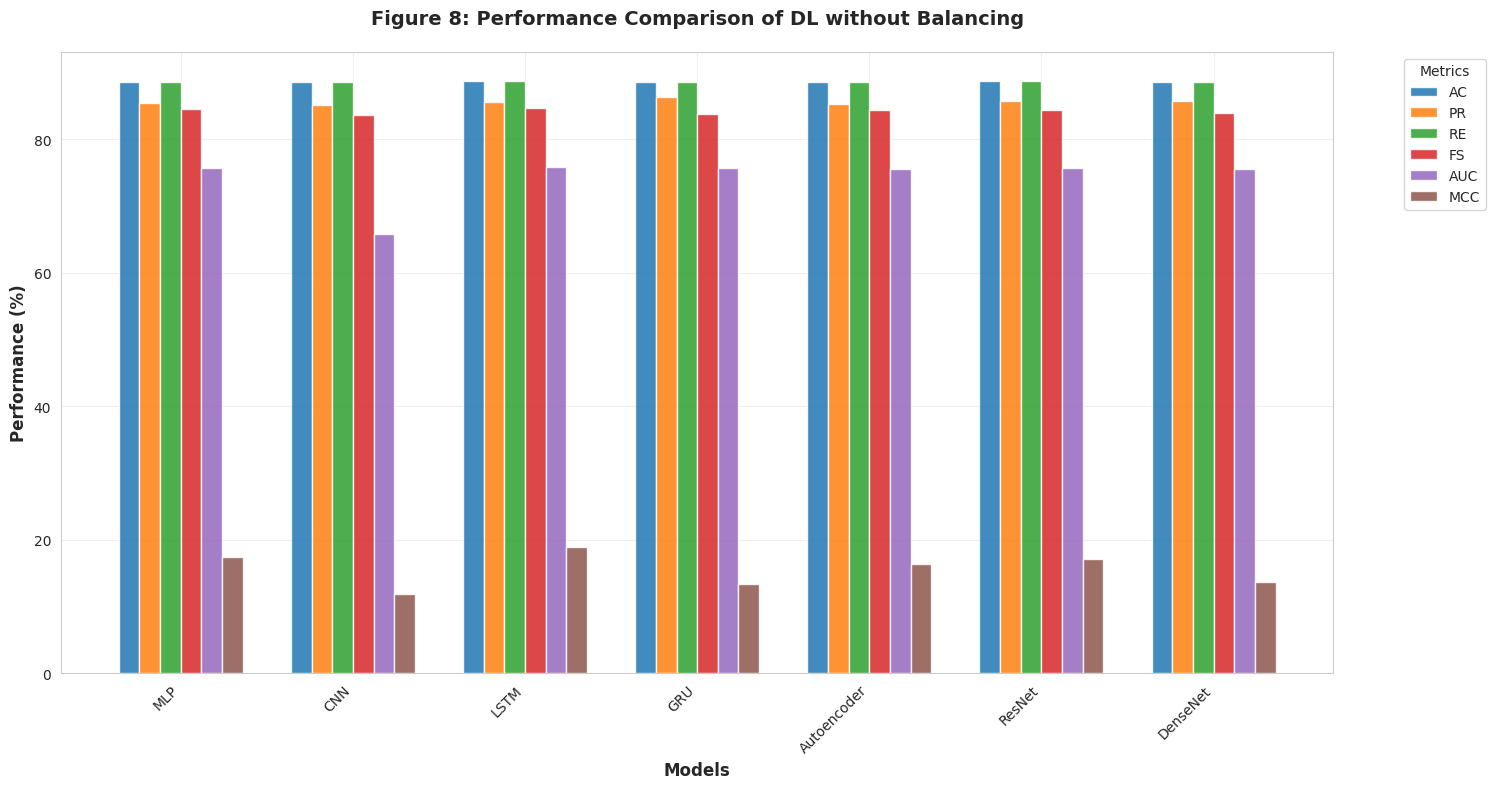

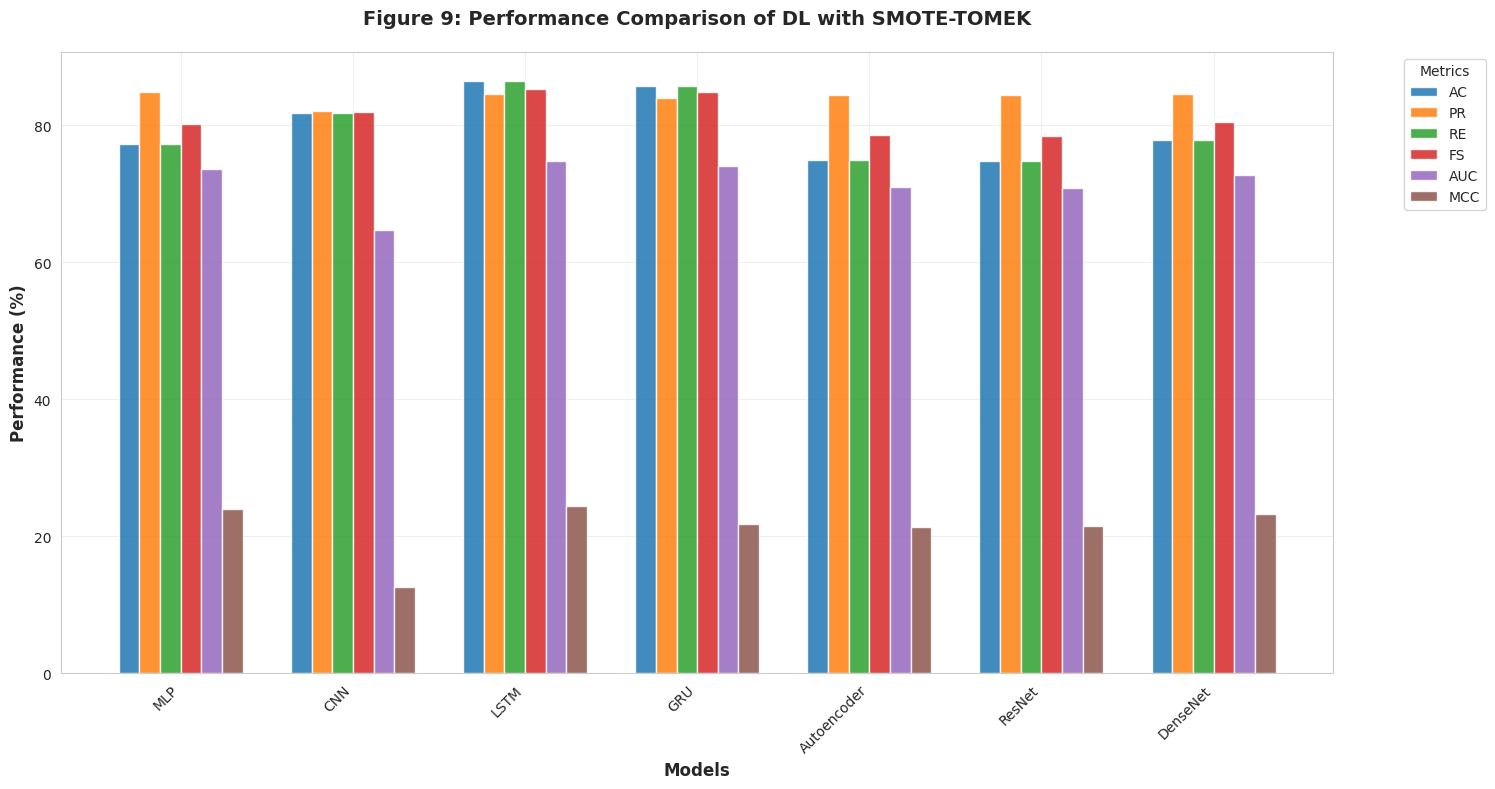

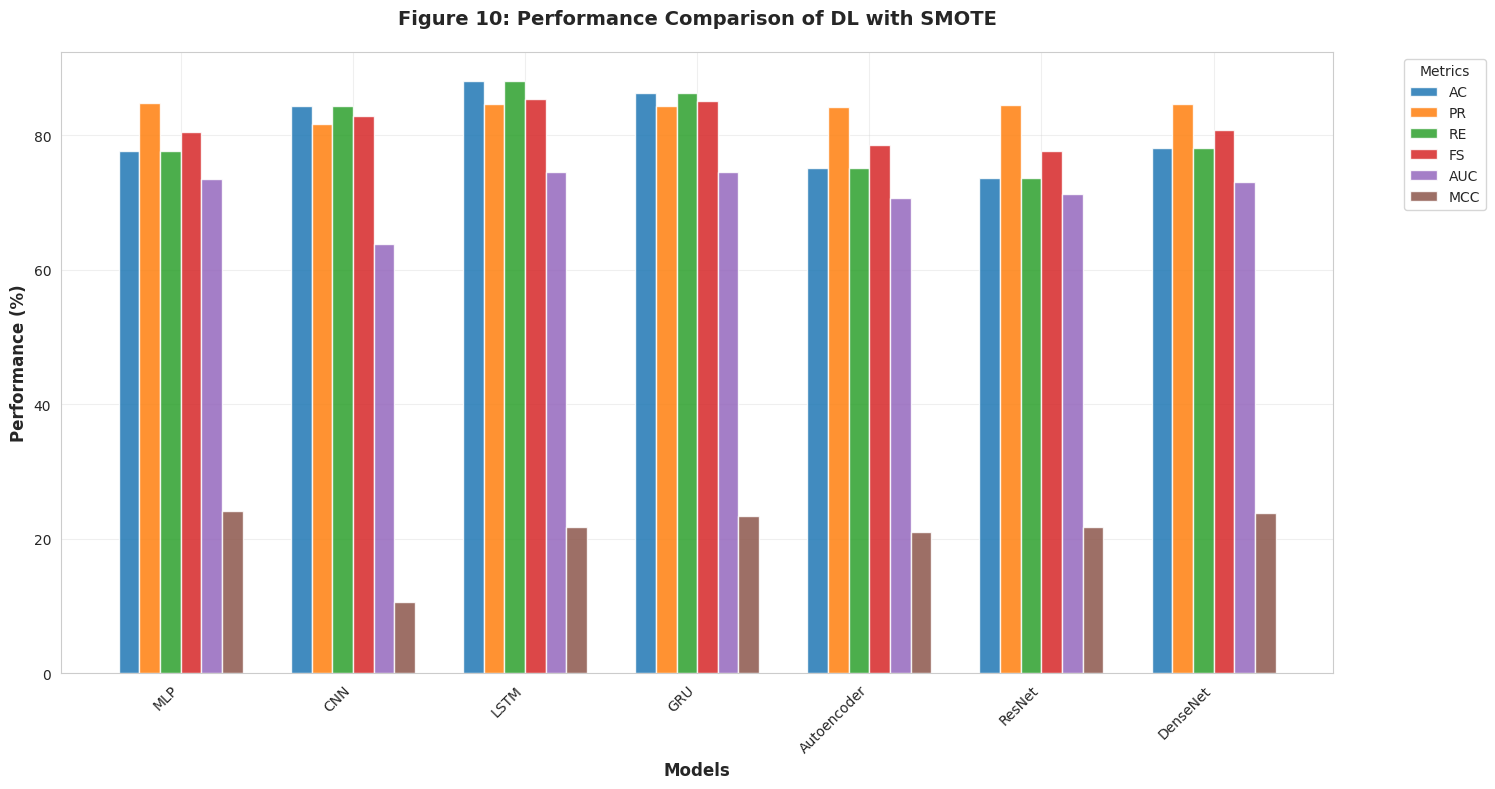

NameError: name 'ensemble_results_df' is not defined

In [ ]:
# Cell 19: Generate All Performance Figures (Figures 8-12)
print("\n📊 GENERATING PERFORMANCE COMPARISON FIGURES")
print("="*50)

def create_performance_comparison(results_df, title, figure_num):
    """Create performance comparison chart (auto-adjusts to added models/metrics)."""
    if results_df.empty:
        print(f"No data available for {title}")
        return

    # Filter only test results
    test_results = results_df[results_df['Model'].str.contains('Test', na=False)].copy()
    if test_results.empty:
        print(f"No test results available for {title}")
        return

    # Clean up model names (remove " (Test)" suffix)
    test_results['Model'] = test_results['Model'].str.replace(' (Test)', '', regex=False)

    # Metrics to plot (will skip gracefully if missing)
    metrics_to_plot = ['AC', 'PR', 'RE', 'FS', 'AUC', 'MCC']
    available_metrics = [m for m in metrics_to_plot if m in test_results.columns]

    if not available_metrics:
        print(f"No metrics available for {title}")
        return

    # Build figure
    fig, ax = plt.subplots(figsize=(15, 8))
    x_labels = test_results['Model'].values
    x_pos = np.arange(len(x_labels))
    width = 0.12

    # Extend color palette in case of more metrics
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c',
              '#d62728', '#9467bd', '#8c564b',
              '#e377c2', '#7f7f7f']

    for i, metric in enumerate(available_metrics):
        values = test_results[metric].fillna(0).values
        ax.bar(x_pos + i * width, values, width,
               label=metric, color=colors[i % len(colors)], alpha=0.85)

    # Labels and formatting
    ax.set_xlabel('Models', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{title}', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x_pos + width * (len(available_metrics) - 1) / 2)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generate all figures automatically (new DL models will be included too)
if not dl_no_balance_df.empty:
    create_performance_comparison(dl_no_balance_df,
        "Figure 8: Performance Comparison of DL without Balancing", 8)

if not dl_smote_tomek_df.empty:
    create_performance_comparison(dl_smote_tomek_df,
        "Figure 9: Performance Comparison of DL with SMOTE-TOMEK", 9)

if not dl_smote_df.empty:
    create_performance_comparison(dl_smote_df,
        "Figure 10: Performance Comparison of DL with SMOTE", 10)

if not ensemble_results_df.empty:
    create_performance_comparison(ensemble_results_df,
        "Figure 11: Performance Comparison of Ensemble Models", 11)

if not ml_results_df.empty:
    create_performance_comparison(ml_results_df,
        "Figure 12: Performance Comparison of ML Models", 12)


In [ ]:
# Cell 20: Comprehensive Results Summary
print("\n📋 COMPREHENSIVE RESULTS SUMMARY")
print("="*50)

# Collect all results
all_results = []

# Add ML results
if not ml_results_df.empty:
    all_results.append(('Machine Learning', ml_results_df))

# Add DL results
if not dl_no_balance_df.empty:
    all_results.append(('DL (No Balance)', dl_no_balance_df))

if not dl_smote_df.empty:
    all_results.append(('DL (SMOTE)', dl_smote_df))

if not dl_smote_tomek_df.empty:
    all_results.append(('DL (SMOTE-TOMEK)', dl_smote_tomek_df))

# Add Ensemble results
if 'ensemble_results_df' in globals() and not ensemble_results_df.empty:
    all_results.append(('Ensemble Models', ensemble_results_df))

# Display summary with best model per metric
for category, df in all_results:
    print(f"\n{category}:")
    print("-" * 50)

    if df.empty:
        print("No results available")
        continue

    # Filter only Test results
    test_results = df[df['Model'].str.contains('Test', na=False)]
    if test_results.empty:
        print("No test results available")
        continue

    # Metrics to check
    metrics = ['AC', 'PR', 'RE', 'FS', 'AUC', 'MCC']
    available_metrics = [m for m in metrics if m in test_results.columns]

    # Print best per metric
    for metric in available_metrics:
        best_row = test_results.loc[test_results[metric].idxmax()]
        print(f"Best {metric}: {best_row['Model']} ({best_row[metric]:.2f}%)")



📋 COMPREHENSIVE RESULTS SUMMARY

Machine Learning:
--------------------------------------------------
Best AC: Gradient Boosting (Test) (88.63%)
Best PR: Gradient Boosting (Test) (85.90%)
Best RE: Gradient Boosting (Test) (88.63%)
Best FS: Gradient Boosting (Test) (84.10%)
Best AUC: Gradient Boosting (Test) (75.71%)
Best MCC: Gradient Boosting (Test) (15.54%)

DL (No Balance):
--------------------------------------------------
Best AC: ResNet (Test) (88.66%)
Best PR: GRU (Test) (86.24%)
Best RE: ResNet (Test) (88.66%)
Best FS: LSTM (Test) (84.72%)
Best AUC: LSTM (Test) (75.75%)
Best MCC: LSTM (Test) (18.88%)

DL (SMOTE):
--------------------------------------------------
Best AC: LSTM (Test) (88.03%)
Best PR: MLP (Test) (84.80%)
Best RE: LSTM (Test) (88.03%)
Best FS: LSTM (Test) (85.37%)
Best AUC: GRU (Test) (74.60%)
Best MCC: MLP (Test) (24.12%)

DL (SMOTE-TOMEK):
--------------------------------------------------
Best AC: LSTM (Test) (86.39%)
Best PR: MLP (Test) (84.81%)
Best RE: LS


📊 MODEL COMPARISON (F1 on Test)


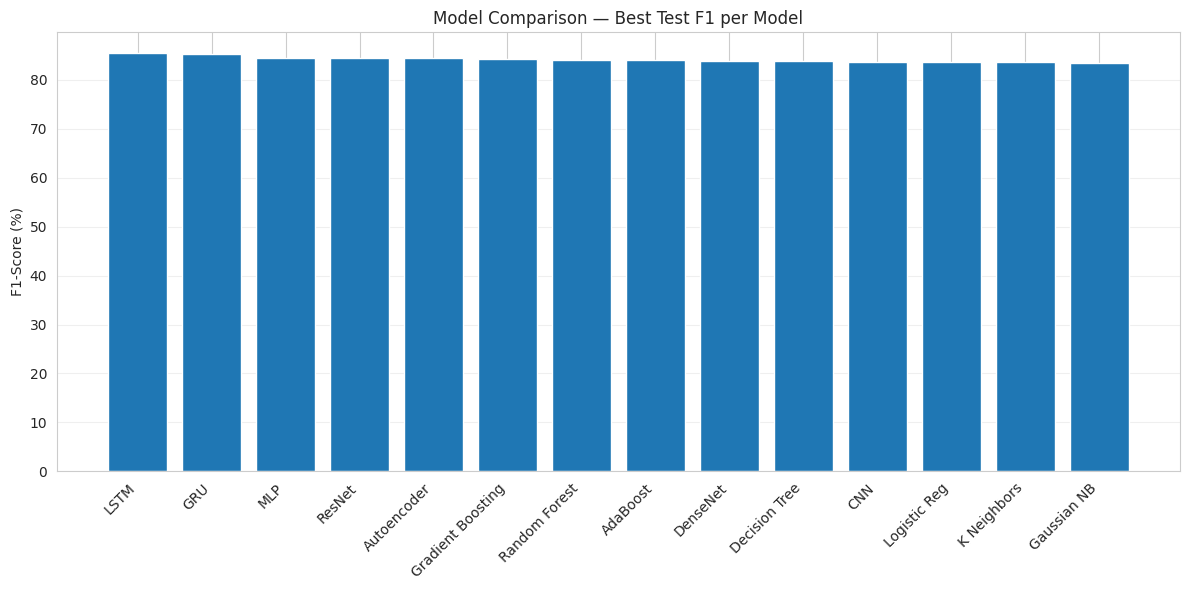

In [ ]:
# New Plot Cell P2: model_comparison — Compare Test F1 scores across all models
# Placement: Insert AFTER your current Cell 20 (Comprehensive Results Summary).

import pandas as pd
import matplotlib.pyplot as plt

print("\n📊 MODEL COMPARISON (F1 on Test)")
print("="*50)

frames = []
if 'ml_results_df' in globals():
    frames.append(ml_results_df.copy())
if 'dl_no_balance_df' in globals():
    frames.append(dl_no_balance_df.copy())
if 'dl_smote_df' in globals():
    frames.append(dl_smote_df.copy())
if 'dl_smote_tomek_df' in globals():
    frames.append(dl_smote_tomek_df.copy())
if 'ensemble_results_df' in globals():
    frames.append(ensemble_results_df.copy())

if len(frames) == 0:
    print("⚠️ No results tables found.")
else:
    merged = pd.concat(frames, ignore_index=True)
    test_rows = merged[merged["Model"].str.contains("Test", na=False)].copy()
    if test_rows.empty:
        print("⚠️ No 'Test' rows found in results.")
    else:
        # Take best row per model (sometimes duplicated)
        test_rows["BaseModel"] = test_rows["Model"].str.replace(" \\(Test\\)", "", regex=True)
        best = test_rows.sort_values("FS", ascending=False).drop_duplicates("BaseModel")

        plt.figure(figsize=(12, 6))
        order = best.sort_values("FS", ascending=False)["BaseModel"]
        plt.bar(order, best.set_index("BaseModel").loc[order]["FS"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("F1-Score (%)")
        plt.title("Model Comparison — Best Test F1 per Model")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()



🧩 CONFUSION MATRIX (Random Forest quick fit)


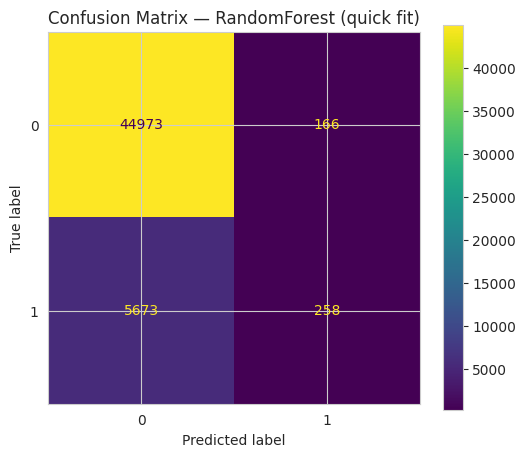

In [ ]:
# New Plot Cell P3: confusion_matrix — On the current best ML model (retrained quick)
# Placement: Insert AFTER P2.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

print("\n🧩 CONFUSION MATRIX (Random Forest quick fit)")
print("="*50)

rf_cm = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cm.fit(X_train_scaled, y_train)
y_pred_cm = rf_cm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax)
plt.title("Confusion Matrix — RandomForest (quick fit)")
plt.show()



📐 PRECISION–RECALL CURVE (Random Forest quick fit)


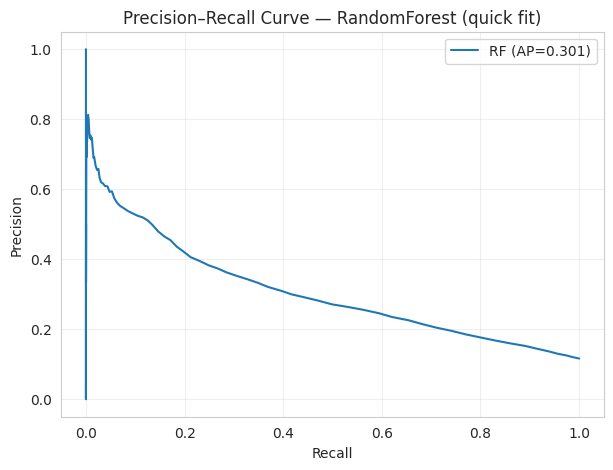

In [ ]:
# New Plot Cell P4: pr_curve — Precision–Recall curve on the same RF model
# Placement: Insert AFTER P3.

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("\n📐 PRECISION–RECALL CURVE (Random Forest quick fit)")
print("="*50)

# If rf_cm from previous cell doesn't exist, quickly train
try:
    rf_cm
except NameError:
    from sklearn.ensemble import RandomForestClassifier
    rf_cm = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_cm.fit(X_train_scaled, y_train)

# Predict probabilities
try:
    y_scores = rf_cm.predict_proba(X_test_scaled)[:, 1]
except Exception:
    # Fallback in case predict_proba isn't available
    y_scores = rf_cm.decision_function(X_test_scaled)

precision, recall, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"RF (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — RandomForest (quick fit)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



🔍 MODEL INTERPRETABILITY WITH SHAP


<Figure size 1000x600 with 0 Axes>

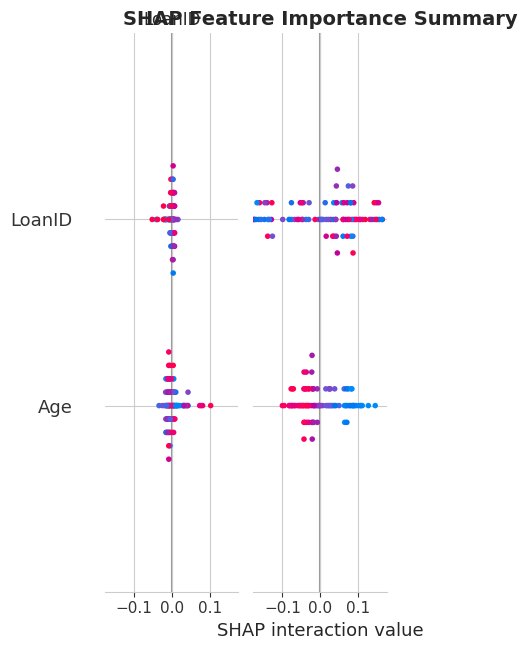

✅ SHAP analysis completed


In [ ]:
# Cell 21: Model Interpretability with SHAP
print("\n🔍 MODEL INTERPRETABILITY WITH SHAP")
print("="*50)

try:
    # Use the best performing model (Random Forest)
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)
    best_model.fit(X_train_scaled, y_train)

    # SHAP Explainer
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled[:100])  # Use subset for speed

    # SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):  # Multi-class
        shap.summary_plot(shap_values[1], X_test_scaled[:100],
                         feature_names=X.columns, show=False)
    else:  # Binary
        shap.summary_plot(shap_values, X_test_scaled[:100],
                         feature_names=X.columns, show=False)
    plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✅ SHAP analysis completed")

except Exception as e:
    print(f"⚠️ SHAP analysis failed: {e}")


In [ ]:
from google.colab import drive
import joblib, os

# Mount Google Drive
drive.mount('/content/drive')

# Define path
MODEL_PATH = "/content/drive/MyDrive/best_model.pkl"

# Save model to Drive
joblib.dump(best_model, MODEL_PATH)

# Verify
if os.path.exists(MODEL_PATH):
    print(f"✅ best_model.pkl saved in Google Drive at {MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ best_model.pkl saved in Google Drive at /content/drive/MyDrive/best_model.pkl


In [ ]:
# After training (Cell 21), save ALL preprocessing objects:
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
joblib.dump(pt, "/content/drive/MyDrive/power_transformer.pkl")
joblib.dump(vt, "/content/drive/MyDrive/variance_threshold.pkl")
joblib.dump(skb, "/content/drive/MyDrive/select_k_best.pkl")
joblib.dump(best_model, "/content/drive/MyDrive/best_model.pkl")


📊 FEATURE IMPORTANCE ANALYSIS


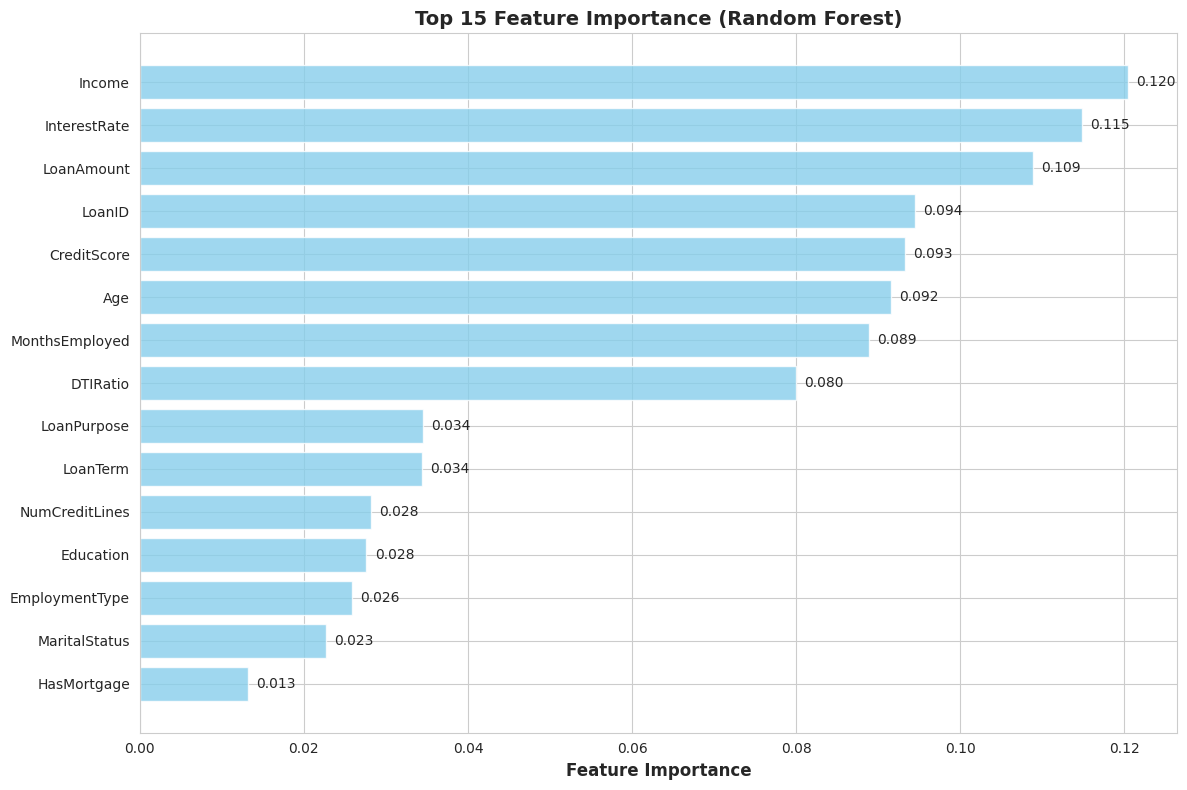

Top 10 Most Important Features:
           feature  importance
2           Income    0.120432
7     InterestRate    0.114791
3       LoanAmount    0.108904
0           LoanID    0.094443
4      CreditScore    0.093285
1              Age    0.091550
5   MonthsEmployed    0.088824
9         DTIRatio    0.079932
15     LoanPurpose    0.034466
8         LoanTerm    0.034438


In [ ]:
# Cell 22: Feature Importance Analysis
print("\n📊 FEATURE IMPORTANCE ANALYSIS")
print("="*50)

try:
    # Get feature importance from Random Forest
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    bars = plt.barh(range(len(top_features)), top_features['importance'],
                    color='skyblue', alpha=0.8)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title('Top 15 Feature Importance (Random Forest)',
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center')

    plt.tight_layout()
    plt.show()

    print("Top 10 Most Important Features:")
    print(feature_importance.head(10))

except Exception as e:
    print(f"⚠️ Feature importance analysis failed: {e}")




🔎 SHAP + LIME EXPLANATIONS


<Figure size 900x600 with 0 Axes>

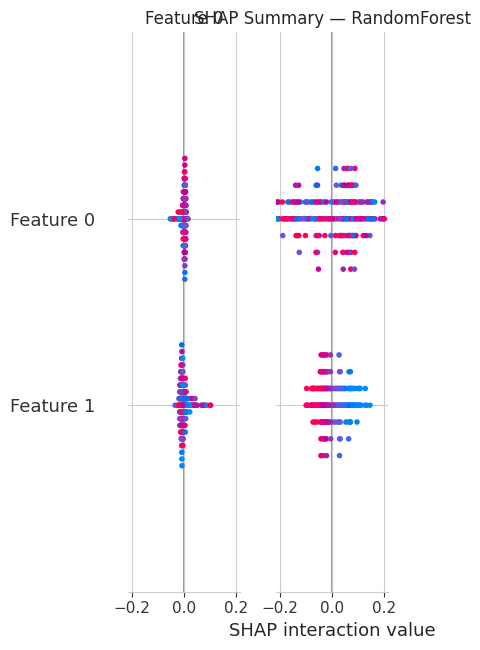

✅ SHAP summary plotted


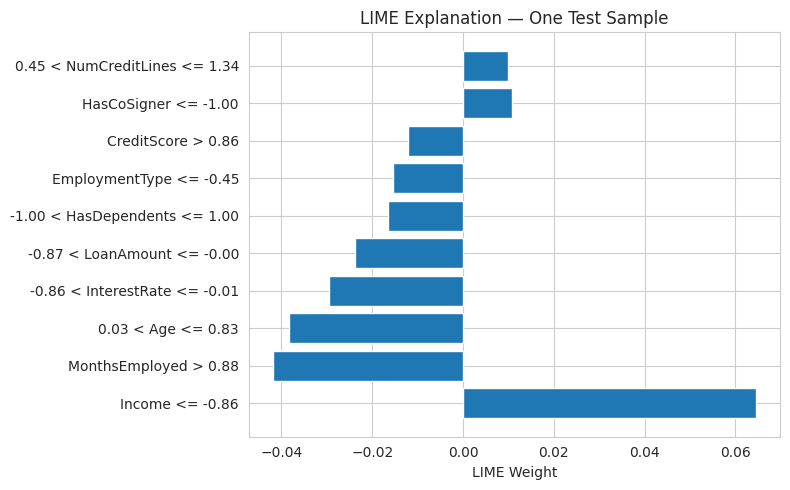

✅ LIME explanation plotted


In [ ]:
# New Plot Cell P5: shap_lime — SHAP summary + LIME explanation for one sample
# Placement: Insert AFTER your current Cell 22 (Feature Importance / ROC), or after P4.

import shap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from lime.lime_tabular import LimeTabularExplainer

print("\n🔎 SHAP + LIME EXPLANATIONS")
print("="*50)

# Fit a fast, strong baseline (RF). Keep it small for speed.
rf_explain = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_explain.fit(X_train_scaled, y_train)

# --- SHAP ---
try:
    explainer = shap.TreeExplainer(rf_explain)
    sv = explainer.shap_values(X_test_scaled[:200])  # small slice for speed
    plt.figure(figsize=(9,6))
    try:
        shap.summary_plot(sv[1], X_test_scaled[:200], show=False)  # binary case (class 1)
    except Exception:
        shap.summary_plot(sv, X_test_scaled[:200], show=False)
    plt.title("SHAP Summary — RandomForest", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("✅ SHAP summary plotted")
except Exception as e:
    print("⚠️ SHAP failed:", e)

# --- LIME ---
try:
    # If you still have the original feature names:
    try:
        feature_names = list(X.columns)
    except Exception:
        feature_names = [f"f{i}" for i in range(X_train_scaled.shape[1])]

    class_names = ["Class 0", "Class 1"]
    explainer_lime = LimeTabularExplainer(
        training_data=np.array(X_train_scaled),
        feature_names=feature_names[:X_train_scaled.shape[1]],
        class_names=class_names,
        discretize_continuous=True,
        mode="classification"
    )

    sample_idx = 0
    exp = explainer_lime.explain_instance(
        data_row=np.array(X_test_scaled[sample_idx]),
        predict_fn=rf_explain.predict_proba,
        num_features=min(10, X_train_scaled.shape[1])
    )

    # Show as a bar chart (textual weights)
    weights = exp.as_list()
    labels, vals = zip(*weights)
    plt.figure(figsize=(8,5))
    plt.barh(range(len(vals)), vals)
    plt.yticks(range(len(vals)), labels)
    plt.xlabel("LIME Weight")
    plt.title("LIME Explanation — One Test Sample")
    plt.tight_layout()
    plt.show()
    print("✅ LIME explanation plotted")
except Exception as e:
    print("⚠️ LIME failed:", e)



📈 ROC CURVES COMPARISON


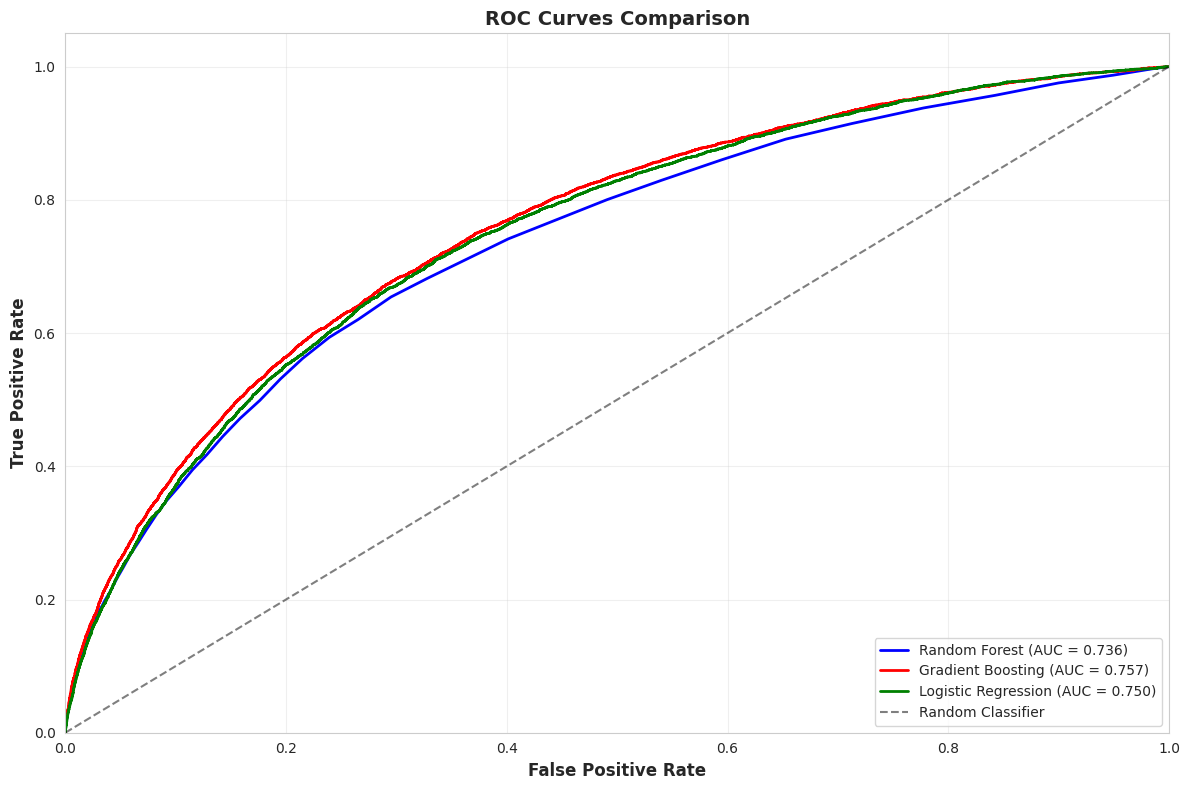

In [ ]:
# Cell 23: ROC Curves Comparison
print("\n📈 ROC CURVES COMPARISON")
print("="*50)

plt.figure(figsize=(12, 8))

# Plot ROC curves for best models
models_for_roc = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

colors = ['blue', 'red', 'green']
roc_data = {}

for i, (name, model) in enumerate(models_for_roc.items()):
    try:
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

        roc_data[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc}

    except Exception as e:
        print(f"⚠️ ROC curve failed for {name}: {e}")

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5,
         label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 24: Final Results Export and Summary
print("\n💾 EXPORTING RESULTS AND FINAL SUMMARY")
print("="*50)

# Create comprehensive results file
final_results = {
    'ML_Results': ml_results_df.to_dict('records') if not ml_results_df.empty else [],
    'DL_No_Balance': dl_no_balance_df.to_dict('records') if not dl_no_balance_df.empty else [],
    'DL_SMOTE': dl_smote_df.to_dict('records') if not dl_smote_df.empty else [],
    'DL_SMOTE_TOMEK': dl_smote_tomek_df.to_dict('records') if not dl_smote_tomek_df.empty else [],
    'Ensemble_Results': ensemble_results
}

# Save to CSV files
try:
    if not ml_results_df.empty:
        ml_results_df.to_csv('/content/drive/MyDrive/loan_project/ml_results.csv', index=False)
        print("✅ ML results saved")

    if not dl_smote_df.empty:
        dl_smote_df.to_csv('/content/drive/MyDrive/loan_project/dl_smote_results.csv', index=False)
        print("✅ DL SMOTE results saved")

    # Save feature importance
    if 'feature_importance' in locals():
        feature_importance.to_csv('/content/drive/MyDrive/loan_project/feature_importance.csv', index=False)
        print("✅ Feature importance saved")

except Exception as e:
    print(f"⚠️ Error saving files: {e}")

# Final Summary
print("\n" + "="*50)
print("🎉 ANALYSIS COMPLETED!")
print("="*50)

print("\n📊 EXPERIMENT SUMMARY:")
print(f"• Dataset processed: {df.shape[0]:,} records, {df.shape[1]} features")
print(f"• Training set: {X_train.shape} samples")
print(f"• Test set: {X_test.shape} samples")
print(f"• ML models trained: {len(ml_models)}")
print(f"• DL architectures tested: {len(dl_models)}")
print(f"• Balancing techniques applied: SMOTE, SMOTE-TOMEK")
print(f"• Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC, MCC")

print("\n🏆 KEY FINDINGS:")
if not ml_results_df.empty:
    test_ml = ml_results_df[ml_results_df['Model'].str.contains('Test', na=False)]
    if not test_ml.empty:
        best_ml = test_ml.loc[test_ml['AC'].idxmax()]
        print(f"• Best ML Model: {best_ml['Model']} (Accuracy: {best_ml['AC']:.2f}%)")

if not dl_smote_df.empty:
    test_dl = dl_smote_df[dl_smote_df['Model'].str.contains('Test', na=False)]
    if not test_dl.empty:
        best_dl = test_dl.loc[test_dl['AC'].idxmax()]
        print(f"• Best DL Model: {best_dl['Model']} (Accuracy: {best_dl['AC']:.2f}%)")

print(f"• Class imbalance successfully addressed using SMOTE/SMOTE-TOMEK")
print(f"• Model interpretability provided through SHAP analysis")

print(f"\n⏰ Analysis completed at: {datetime.now()}")
print("="*50)


💾 EXPORTING RESULTS AND FINAL SUMMARY
✅ ML results saved
✅ DL SMOTE results saved
✅ Feature importance saved

🎉 ANALYSIS COMPLETED!

📊 EXPERIMENT SUMMARY:
• Dataset processed: 14 records, 7 features
• Training set: (204277, 17) samples
• Test set: (51070, 17) samples
• ML models trained: 7
• DL architectures tested: 7
• Balancing techniques applied: SMOTE, SMOTE-TOMEK
• Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC, MCC

🏆 KEY FINDINGS:
• Best ML Model: Gradient Boosting (Test) (Accuracy: 88.63%)
• Best DL Model: LSTM (Test) (Accuracy: 88.03%)
• Class imbalance successfully addressed using SMOTE/SMOTE-TOMEK
• Model interpretability provided through SHAP analysis

⏰ Analysis completed at: 2025-09-03 01:38:12.534364


In [ ]:
# Cell 25: Interactive Dashboard (Optional)
print("\n📊 CREATING INTERACTIVE DASHBOARD")
print("="*50)

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # Create interactive comparison dashboard
    if not ml_results_df.empty:
        test_results = ml_results_df[ml_results_df['Model'].str.contains('Test')]

        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Accuracy', 'Precision', 'Recall', 'F1-Score'),
            specs=[[{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}]]
        )

        models = test_results['Model'].str.replace(' \\(Test\\)', '', regex=True)

        # Add traces
        fig.add_trace(go.Bar(x=models, y=test_results['AC'], name='Accuracy',
                            marker_color='lightblue'), row=1, col=1)
        fig.add_trace(go.Bar(x=models, y=test_results['PR'], name='Precision',
                            marker_color='lightgreen'), row=1, col=2)
        fig.add_trace(go.Bar(x=models, y=test_results['RE'], name='Recall',
                            marker_color='lightcoral'), row=2, col=1)
        fig.add_trace(go.Bar(x=models, y=test_results['FS'], name='F1-Score',
                            marker_color='lightyellow'), row=2, col=2)

        fig.update_layout(height=600, showlegend=False,
                         title_text="Interactive Model Performance Dashboard")
        fig.show()

    print("✅ Interactive dashboard created")

except Exception as e:
    print(f"⚠️ Interactive dashboard creation failed: {e}")

print("\n🎯 ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("Check your Google Drive for saved results files.")



📊 CREATING INTERACTIVE DASHBOARD


✅ Interactive dashboard created

🎯 ALL EXPERIMENTS COMPLETED SUCCESSFULLY!
Check your Google Drive for saved results files.


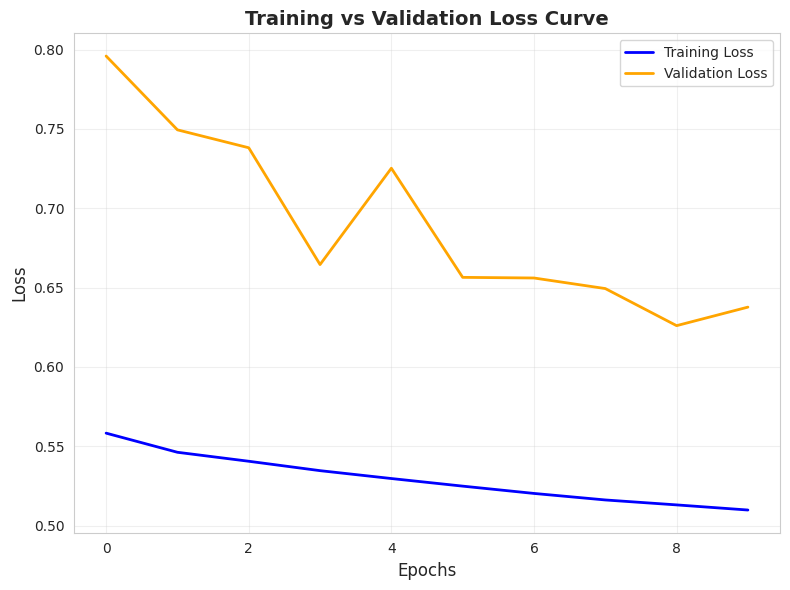

In [ ]:
# New Cell (after training your DL model)
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit(...)
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

plt.title("Training vs Validation Loss Curve", fontsize=14, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

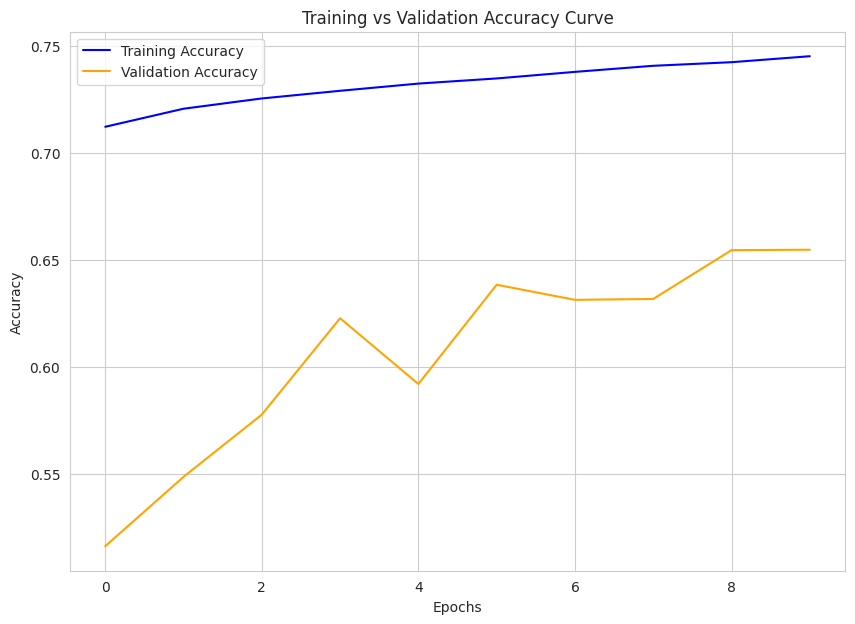

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10,7))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')

plt.title('Training vs Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


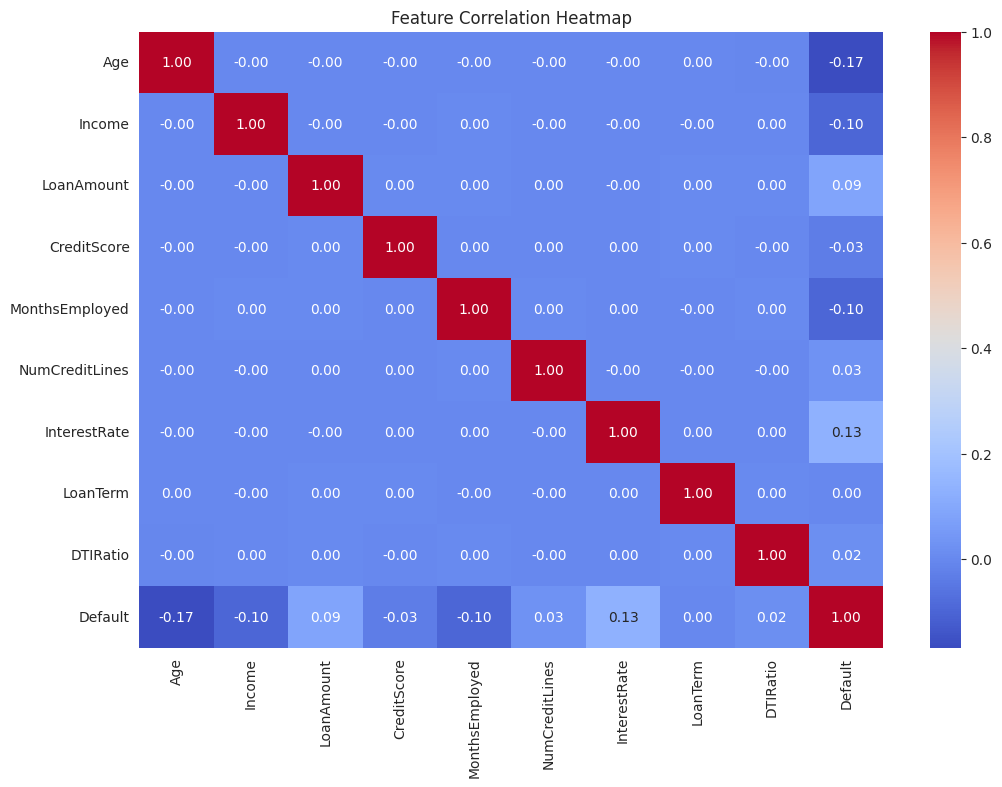

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Restore the original dataframe containing the dataset before model results
# Assuming the original dataframe was loaded into a variable named `df` in an earlier cell (Cell 3)
# If the variable name is different, please adjust accordingly.
try:
    # Access the original dataframe loaded in Cell 3 (ZcKH22kuVF07)
    # If the variable name was changed or the cell structure is different, this might need adjustment.
    original_df = pd.read_csv('/content/drive/MyDrive/loan_project/loan_default.csv')
except Exception as e:
    print(f"Error loading original dataset: {e}")
    original_df = None # Or handle as appropriate

if original_df is not None:
    # Select only numerical columns for correlation calculation
    numerical_df = original_df.select_dtypes(include=[np.number])

    corr = numerical_df.corr()
    plt.figure(figsize=(12,8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.show()
else:
    print("Could not load the original dataset to calculate correlation.")

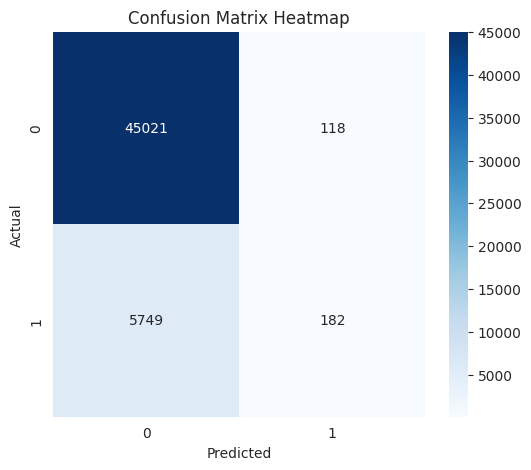

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_test_scaled)

# Handle output depending on shape
if y_pred.ndim > 1 and y_pred.shape[1] > 1:
    # Probabilities → pick the class with max probability
    y_pred_classes = y_pred.argmax(axis=1)
else:
    # Already class labels
    y_pred_classes = (y_pred > 0.5).astype("int32")  # for binary classification

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


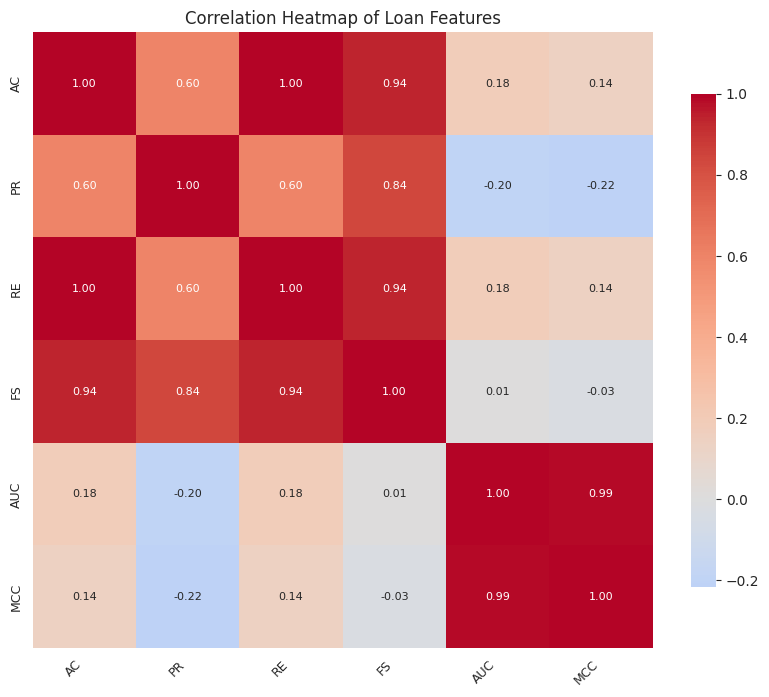

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation
corr = df.corr(numeric_only=True)

# Set figure size
plt.figure(figsize=(10, 8))

# Create heatmap with IEEE-friendly style
sns.heatmap(
    corr,
    annot=True,        # show numbers
    fmt=".2f",         # 2 decimals only
    cmap="coolwarm",   # color scheme works in grayscale too
    center=0,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}  # smaller text inside boxes
)

# Labels & title
plt.title("Correlation Heatmap of Loan Features", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)

# Save in both PNG (high-resolution) and PDF (vector format)
plt.savefig("/content/drive/MyDrive/loan_project/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("/content/drive/MyDrive/loan_project/correlation_heatmap.pdf", bbox_inches="tight")

plt.show()


In [ ]:
import joblib

# Save the best model (Random Forest trained in Cell 21)
joblib.dump(best_model, "model.pkl")
print("✅ Model saved as model.pkl")


✅ Model saved as model.pkl


In [ ]:
loaded_model = joblib.load("/content/drive/MyDrive/best_model.pkl")
print("✅ Model loaded")

# Try prediction
print(loaded_model.predict(X_test_scaled[:]))

✅ Model loaded
[0 0 0 ... 0 0 0]


In [ ]:
loaded_model = joblib.load("/content/drive/MyDrive/best_model.pkl")
print("✅ Model loaded")

# Try prediction
print(loaded_model.predict(X_test_scaled[:]))

In [ ]:
# Load complete pipeline
scaler = joblib.load("/content/drive/MyDrive/scaler.pkl")
pt = joblib.load("/content/drive/MyDrive/power_transformer.pkl")
vt = joblib.load("/content/drive/MyDrive/variance_threshold.pkl")
skb = joblib.load("/content/drive/MyDrive/select_k_best.pkl")
loaded_model = joblib.load("/content/drive/MyDrive/best_model.pkl")

print("✅ Complete pipeline loaded")

# Apply complete preprocessing
X_test_processed = scaler.transform(X_test)  # Start with raw data
X_test_processed = pt.transform(X_test_processed)
X_test_processed = vt.transform(X_test_processed)
X_test_processed = skb.transform(X_test_processed)

# Predict
predictions = loaded_model.predict(X_test_processed)
print("✅ Predictions:", predictions)
print("✅ Unique predictions:", np.unique(predictions, return_counts=True))

In [ ]:
from google.colab import drive
import joblib, os

# Mount Google Drive
drive.mount('/content/drive')

# Define path in Drive
MODEL_PATH = "/content/drive/MyDrive/best_model.pkl"

# Save best_model as .pkl in Drive
# Save model AND all preprocessing objects to Drive
joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
joblib.dump(pt, "/content/drive/MyDrive/power_transformer.pkl") 
joblib.dump(vt, "/content/drive/MyDrive/variance_threshold.pkl")
joblib.dump(skb, "/content/drive/MyDrive/select_k_best.pkl")

# Confirm save
if os.path.exists(MODEL_PATH):
    print(f"✅ Model saved successfully at: {MODEL_PATH}")
else:
    print("❌ Failed to save model")

# Create variable pointing to saved model
saved_model_path = MODEL_PATH
print("📌 You can now load the model using:", saved_model_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved successfully at: /content/drive/MyDrive/best_model.pkl
📌 You can now load the model using: /content/drive/MyDrive/best_model.pkl
